# Explainable AI (XAI) aplicada a mantenimiento predictivo

**¿Por qué el modelo dice que esta máquina va a fallar?**

Aprendizaje Automático · MCDA 2026-2 · Universidad EAFIT · Profesor: Andrés Vásquez Restrepo
Exposición — Temas avanzados de ML · Tema: *Explainable AI*
Autores: **[Nombre 1]** y **[Nombre 2]**

---

### La idea en tres frases

1. Entrenamos un modelo de **caja negra** (XGBoost) que predice si una máquina de mecanizado va a fallar.
2. Lo abrimos con cuatro técnicas de XAI: **importancia por permutación**, **PDP/ICE**, **SHAP** y **LIME**.
3. Como este dataset fue generado con **reglas físicas conocidas**, podemos hacer algo que casi nunca se puede: **comprobar si las explicaciones dicen la verdad**.

### Contenido

| # | Sección | Pregunta que responde |
|---|---|---|
| 0 | [Preparación del entorno](#s0) | ¿Qué necesito para ejecutar esto? |
| 1 | [El problema y los datos](#s1) | ¿Qué queremos predecir y con qué? |
| 2 | [Preparación de los datos](#s2) | ¿Qué entra al modelo y qué no? |
| 3 | [Modelos transparentes](#s3) | ¿Alcanza con un modelo que se explica solo? |
| 4 | [La caja negra: XGBoost](#s4) | ¿Cuánto mejora un modelo complejo? |
| 5 | [Explicaciones globales](#s5) | ¿Qué aprendió el modelo en general? |
| 6 | [Explicaciones locales](#s6) | ¿Por qué *esta* máquina? |
| 7 | [La prueba de fuego](#s7) | ¿Las explicaciones coinciden con la física real? |
| 8 | [Riesgos y límites de XAI](#s8) | ¿Cuándo una explicación nos puede engañar? |
| 9 | [Cerrar el ciclo](#s9) | ¿Podemos dejar de necesitar la caja negra? |
| 10 | [Conclusiones y referencias](#s10) | ¿Qué nos llevamos? |

> **Cómo leer este notebook.** Antes de cada bloque de código hay una explicación de *qué* se va a hacer y *por qué*. Después de cada resultado hay un recuadro **«Cómo leer esto»** con la interpretación. El notebook se ejecuta completo de arriba a abajo en uno o dos minutos. Las cifras que se citan en el texto corresponden a la ejecución guardada (versiones de `requirements.txt`); con otras versiones de las librerías pueden cambiar en el segundo o tercer decimal, sin alterar las conclusiones.

<a id="s0"></a>
## 0. Preparación del entorno

Instalamos solo lo que falte. En Google Colab ya vienen `numpy`, `pandas`, `scikit-learn`, `matplotlib` y normalmente `xgboost`; las librerías de XAI (`shap` y `lime`) se instalan aquí si no están.

In [1]:
# Instala únicamente las librerías que no estén ya disponibles (útil en Google Colab).
import importlib.util, subprocess, sys

for paquete in ["shap", "lime", "xgboost"]:
    if importlib.util.find_spec(paquete) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", paquete])
print("Entorno listo.")

Entorno listo.


In [2]:
import itertools, math, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             average_precision_score, confusion_matrix)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

from xgboost import XGBClassifier
import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")

# Una sola semilla para todo: garantiza que cada ejecución dé los mismos resultados.
SEMILLA = 42
np.random.seed(SEMILLA)

# Colores con significado fijo en todo el notebook.
AZUL, NARANJA, GRIS = "#2a78d6", "#eb6834", "#52514e"   # sin falla / falla / texto secundario

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.8, "axes.axisbelow": True,
})

# Carpeta donde se guardan las figuras que usamos en la presentación.
CARPETA_FIGURAS = Path("figuras")
CARPETA_FIGURAS.mkdir(exist_ok=True)

def guardar(nombre):
    # Guarda la figura activa como PNG en la carpeta de figuras.
    plt.savefig(CARPETA_FIGURAS / f"{nombre}.png", facecolor="white")

def miles(numero):
    # Formato en español para enteros: 9661 -> "9.661".
    return f"{int(numero):,}".replace(",", ".")

def porcentaje(fraccion, decimales=0):
    # Formato en español para porcentajes: 0.966 -> "96,6 %".
    return f"{fraccion * 100:.{decimales}f}".replace(".", ",") + " %"

def dibujar_arbol(arbol, nombres, eje, tamano_letra=9):
    # Dibuja un árbol de decisión con los colores del notebook (azul = sin falla, naranja = falla)
    # y con los textos de cada caja en español.
    from matplotlib.colors import to_rgb
    plot_tree(arbol, feature_names=nombres, class_names=["sin falla", "falla"],
              rounded=True, impurity=False, fontsize=tamano_letra, ax=eje)
    azul_claro, naranja_claro = np.array(to_rgb("#cfe1f7")), np.array(to_rgb("#f7c4ae"))
    for texto in eje.texts:
        contenido = texto.get_text()
        if "samples" in contenido:                              # es la caja de un nodo
            sin_falla, con_falla = [float(v) for v in re.search(r"value = \[(.+?), (.+?)\]", contenido).groups()]
            fraccion_falla = con_falla / (sin_falla + con_falla)
            texto.get_bbox_patch().set_facecolor((1 - fraccion_falla) * azul_claro + fraccion_falla * naranja_claro)
            contenido = re.sub(r"value = \[.+?\]", f"sin falla / falla = {sin_falla:.0f} / {con_falla:.0f}", contenido)
            texto.set_text(contenido.replace("samples", "procesos").replace("class =", "predice:"))
        elif contenido.strip() in ("True", "False"):            # etiquetas de las dos primeras ramas
            texto.set_text(contenido.replace("True", "Sí").replace("False", "No"))

print("Versiones:", {m.__name__: m.__version__ for m in (np, pd, shap)},
      "| xgboost", __import__("xgboost").__version__,
      "| scikit-learn", __import__("sklearn").__version__)

Versiones: {'numpy': '2.5.3', 'pandas': '3.0.6', 'shap': '0.52.0'} | xgboost 3.4.1 | scikit-learn 1.9.1


<a id="s1"></a>
## 1. El problema y los datos

### 1.1 El problema

Una fresadora trabaja con una herramienta de corte. Cada registro es **un proceso de mecanizado** con cinco lecturas de sensores y la calidad del producto. Queremos predecir **si el proceso termina en falla de la máquina**.

Predecir bien no es suficiente. Si el modelo dice «esta máquina va a fallar», el ingeniero de mantenimiento necesita saber **qué revisar**: ¿la herramienta?, ¿la refrigeración?, ¿la carga? Sin esa respuesta, la alerta no se puede convertir en una acción. Ese es el trabajo de XAI.

### 1.2 El dataset: AI4I 2020 Predictive Maintenance

- **Fuente:** UCI Machine Learning Repository (DOI [10.24432/C5HS5C](https://doi.org/10.24432/C5HS5C)), licencia CC BY 4.0.
- **Autor:** Stephan Matzka (2020), quien lo creó precisamente para un artículo titulado *«Explainable Artificial Intelligence for Predictive Maintenance Applications»*.
- **Naturaleza:** es un dataset **sintético** que imita datos reales de la industria. Lo importante para nosotros: las fallas se generaron con **reglas físicas documentadas**. Esas reglas son nuestra «hoja de respuestas» y las usaremos en la [sección 7](#s7).

La siguiente celda busca el archivo en la carpeta `data/` del repositorio. Si no lo encuentra (por ejemplo, al abrir el notebook suelto en Colab), lo descarga directamente de UCI.

In [3]:
RUTA_LOCAL = Path("data/ai4i2020.csv")
URL_UCI = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"

def cargar_datos():
    # Devuelve el dataset AI4I 2020: primero busca la copia local y, si no está, lo descarga.
    if RUTA_LOCAL.exists():
        return pd.read_csv(RUTA_LOCAL, encoding="utf-8-sig"), f"copia local ({RUTA_LOCAL})"
    try:
        return pd.read_csv(URL_UCI, encoding="utf-8-sig"), "descarga directa de UCI"
    except Exception:
        # Último recurso en Colab: subir el archivo manualmente.
        from google.colab import files
        subido = files.upload()
        return pd.read_csv(next(iter(subido)), encoding="utf-8-sig"), "archivo subido manualmente"

datos_originales, origen = cargar_datos()
print(f"Datos cargados desde: {origen}")
print(f"Filas: {datos_originales.shape[0]:,} | Columnas: {datos_originales.shape[1]} | "
      f"Valores faltantes: {int(datos_originales.isna().sum().sum())}")
datos_originales.head()

Datos cargados desde: copia local (data/ai4i2020.csv)
Filas: 10,000 | Columnas: 14 | Valores faltantes: 0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


> **Cómo leer esto.** Cada fila es un proceso. Las columnas se dividen en tres grupos:
>
> | Grupo | Columnas | ¿Entra al modelo? |
> |---|---|---|
> | Identificadores | `UDI`, `Product ID` | No: no describen la física del proceso |
> | **Variables de proceso** | `Type` (calidad L/M/H), `Air temperature`, `Process temperature`, `Rotational speed`, `Torque`, `Tool wear` | **Sí** |
> | Resultado | `Machine failure` (lo que predecimos) y `TWF`, `HDF`, `PWF`, `OSF`, `RNF` (el *tipo* de falla) | Solo `Machine failure`, como objetivo |

### 1.3 ¿Qué tan frecuente es la falla?

Procesos con falla: 339 de 10,000  ->  3.39%


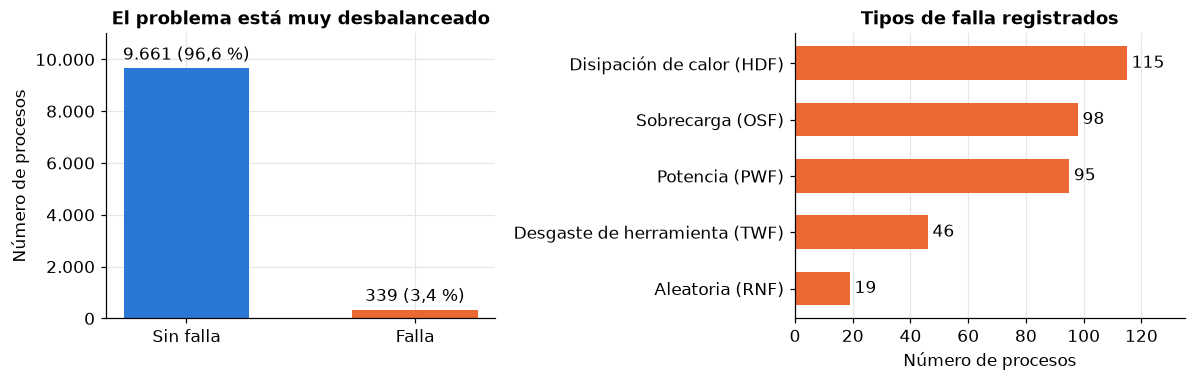

In [4]:
MODOS = ["TWF", "HDF", "PWF", "OSF", "RNF"]
NOMBRE_MODO = {"TWF": "Desgaste de herramienta", "HDF": "Disipación de calor",
               "PWF": "Potencia", "OSF": "Sobrecarga", "RNF": "Aleatoria"}

n_fallas = int(datos_originales["Machine failure"].sum())
tasa = datos_originales["Machine failure"].mean()
print(f"Procesos con falla: {n_fallas} de {len(datos_originales):,}  ->  {tasa:.2%}")

fig, ejes = plt.subplots(1, 2, figsize=(11, 3.6))

# Panel izquierdo: el desbalance de clases.
conteo = datos_originales["Machine failure"].value_counts().sort_index()
barras = ejes[0].bar(["Sin falla", "Falla"], conteo.values, color=[AZUL, NARANJA], width=0.55)
ejes[0].bar_label(barras, labels=[f"{miles(v)} ({porcentaje(v / len(datos_originales), 1)})" for v in conteo.values], padding=3)
ejes[0].set(title="El problema está muy desbalanceado", ylabel="Número de procesos", ylim=(0, 11000))
ejes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: miles(v)))

# Panel derecho: cuántas fallas hay de cada tipo.
por_modo = datos_originales[MODOS].sum().sort_values()
barras = ejes[1].barh([f"{NOMBRE_MODO[m]} ({m})" for m in por_modo.index], por_modo.values, color=NARANJA, height=0.6)
ejes[1].bar_label(barras, padding=3)
ejes[1].set(title="Tipos de falla registrados", xlabel="Número de procesos", xlim=(0, 135))
ejes[1].grid(axis="y", visible=False)
plt.tight_layout(); guardar("01_desbalance_y_modos"); plt.show()

> **Cómo leer esto.**
> - Solo el **3,39 %** de los procesos falla. Esto tiene una consecuencia directa: un modelo que diga siempre «no falla» acertaría el 96,6 % de las veces y sería completamente inútil. Por eso **no usaremos la exactitud (*accuracy*)** para evaluar.
> - Hay cinco tipos de falla. El modelo **no los verá**: solo aprenderá «falla / no falla». Guardamos los tipos para verificar las explicaciones más adelante.
>
> **Nota de calidad de datos.** Las etiquetas no son perfectamente consistentes: hay 9 procesos marcados como falla sin ningún tipo asociado, y 18 procesos con falla aleatoria (`RNF`) que no figuran como falla de máquina. Es una particularidad conocida del dataset; no lo corregimos para trabajar con los datos tal como fueron publicados.

<a id="s2"></a>
## 2. Preparación de los datos

Tomamos tres decisiones, y cada una tiene una razón:

1. **Eliminamos los identificadores** (`UDI`, `Product ID`). No tienen significado físico; si el modelo los usara, estaría memorizando.
2. **Eliminamos las columnas de tipo de falla** (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`). Esto es fundamental: esas columnas *son* el resultado. Dejarlas sería **fuga de información (*data leakage*)**: el modelo tendría un 100 % de acierto y no serviría para nada, porque en la planta esas columnas no existen antes de la falla.
3. **Codificamos la calidad como número ordenado** (L = 0, M = 1, H = 2), porque tiene un orden natural: baja, media y alta.

También renombramos las columnas a español y sin corchetes (XGBoost no acepta `[` ni `]` en los nombres).

In [5]:
RENOMBRAR = {
    "Air temperature [K]": "temp_aire_K",
    "Process temperature [K]": "temp_proceso_K",
    "Rotational speed [rpm]": "velocidad_rpm",
    "Torque [Nm]": "torque_Nm",
    "Tool wear [min]": "desgaste_min",
}
datos = datos_originales.rename(columns=RENOMBRAR)
datos["calidad"] = datos["Type"].map({"L": 0, "M": 1, "H": 2})     # variable ordinal

VARIABLES = ["calidad", "temp_aire_K", "temp_proceso_K", "velocidad_rpm", "torque_Nm", "desgaste_min"]
OBJETIVO = "Machine failure"

X = datos[VARIABLES].astype(float)     # lo único que verá el modelo
y = datos[OBJETIVO]                    # 1 = falla, 0 = sin falla

X.describe().T[["mean", "std", "min", "max"]].round(1)

,mean,std,min,max
calidad,0.5,0.7,0.0,2.0
temp_aire_K,300.0,2.0,295.3,304.5
temp_proceso_K,310.0,1.5,305.7,313.8
velocidad_rpm,1538.8,179.3,1168.0,2886.0
torque_Nm,40.0,10.0,3.8,76.6
desgaste_min,108.0,63.7,0.0,253.0


### 2.1 División en entrenamiento y prueba

Separamos el 25 % de los datos para **prueba**. El modelo nunca los ve durante el entrenamiento, así que las métricas y las explicaciones que calculemos sobre ellos reflejan cómo se comporta con procesos nuevos.

La división es **estratificada**: mantiene el mismo 3,39 % de fallas en ambos conjuntos. Con una clase tan escasa, una división al azar podría dejar muy pocas fallas en la prueba.

In [6]:
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEMILLA)

# Guardamos también las filas originales de la prueba (con los tipos de falla) para la sección 7.
prueba_original = datos.loc[X_prueba.index]

print(f"Entrenamiento: {len(X_entrena):,} procesos, {int(y_entrena.sum())} fallas ({y_entrena.mean():.2%})")
print(f"Prueba:        {len(X_prueba):,} procesos, {int(y_prueba.sum())} fallas ({y_prueba.mean():.2%})")

Entrenamiento: 7,500 procesos, 254 fallas (3.39%)
Prueba:        2,500 procesos, 85 fallas (3.40%)


### 2.2 Un dato para guardar: hay variables muy correlacionadas

Antes de modelar, miramos cómo se relacionan las variables entre sí. Esto parece un detalle, pero será clave cuando hablemos de los **riesgos** de XAI en la [sección 8](#s8).

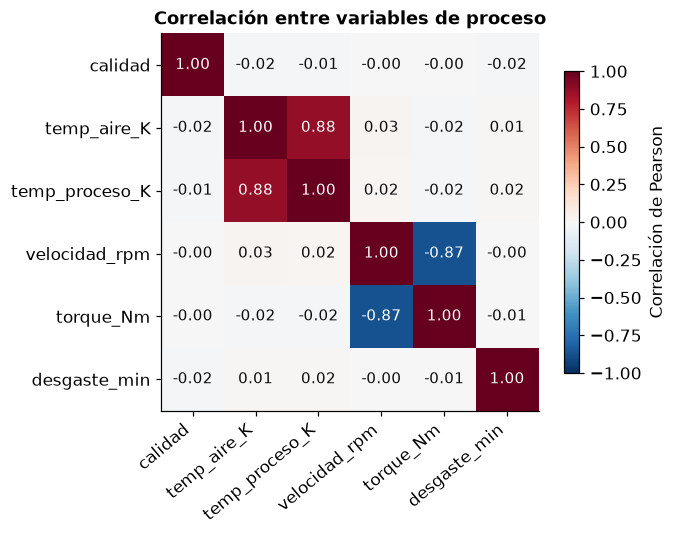

In [7]:
correlacion = X_entrena.corr()

fig, eje = plt.subplots(figsize=(6.4, 5))
imagen = eje.imshow(correlacion, cmap="RdBu_r", vmin=-1, vmax=1)
eje.set_xticks(range(len(VARIABLES)), VARIABLES, rotation=40, ha="right")
eje.set_yticks(range(len(VARIABLES)), VARIABLES)
for i in range(len(VARIABLES)):
    for j in range(len(VARIABLES)):
        valor = correlacion.iloc[i, j]
        eje.text(j, i, f"{valor:.2f}", ha="center", va="center",
                 color="white" if abs(valor) > 0.6 else "#0b0b0b", fontsize=10)
eje.grid(False); eje.set_title("Correlación entre variables de proceso")
plt.colorbar(imagen, ax=eje, shrink=0.8, label="Correlación de Pearson")
plt.tight_layout(); guardar("02_correlaciones"); plt.show()

> **Cómo leer esto.** Hay dos parejas fuertemente ligadas:
> - **Temperatura del aire y del proceso (+0,88):** cuando sube una, sube la otra. Tiene sentido: el proceso se calienta por encima del ambiente.
> - **Velocidad y torque (−0,88):** a más velocidad, menos torque. También tiene sentido físico: la potencia $P = \tau \cdot \omega$ se mantiene en un rango, así que si una sube la otra baja.
>
> Cuando dos variables se mueven juntas, cualquier método de explicación tiene dificultad para decidir **a cuál de las dos darle el crédito**. Lo veremos con datos.

<a id="s3"></a>
## 3. Primer intento: modelos transparentes

Antes de usar una caja negra hay que preguntarse si hace falta. Algunos modelos **se explican solos** (se les llama *interpretables por diseño* o de *caja blanca*):

- **Regresión logística:** cada variable tiene un coeficiente. El coeficiente *es* la explicación.
- **Árbol de decisión pequeño:** se lee como un diagrama de flujo de preguntas sí/no.

### 3.1 Cómo vamos a medir

Como la falla es rara, usamos cuatro métricas centradas en la clase «falla»:

| Métrica | Pregunta que responde | En la planta |
|---|---|---|
| **Precisión** | De las alertas que dio el modelo, ¿cuántas eran fallas reales? | Evita paradas innecesarias |
| **Sensibilidad (*recall*)** | De las fallas reales, ¿cuántas detectó? | Evita fallas no anticipadas |
| **F1** | Media armónica de las dos anteriores | Resume el equilibrio |
| **PR-AUC** | Calidad del ordenamiento de riesgo, sin fijar un umbral | Compara modelos de forma justa |

In [8]:
resultados = []     # aquí vamos acumulando una fila por modelo

def evaluar(nombre, modelo, X_eval, interpretable):
    # Calcula las métricas de un modelo ya entrenado sobre el conjunto de prueba y las registra.
    probabilidad = modelo.predict_proba(X_eval)[:, 1]
    prediccion = (probabilidad >= 0.5).astype(int)
    vn, fp, fn, vp = confusion_matrix(y_prueba, prediccion).ravel()
    fila = {
        "Modelo": nombre,
        "¿Se lee directamente?": "Sí" if interpretable else "No",
        "Precisión": precision_score(y_prueba, prediccion),
        "Sensibilidad": recall_score(y_prueba, prediccion),
        "F1": f1_score(y_prueba, prediccion),
        "PR-AUC": average_precision_score(y_prueba, probabilidad),
        "Fallas detectadas": f"{vp} de {vp + fn}",
        "Falsas alarmas": fp,
    }
    resultados.append(fila)
    return pd.DataFrame([fila]).set_index("Modelo").round(3)

### 3.2 Regresión logística

Estandarizamos las variables (media 0, desviación 1) para que los coeficientes sean comparables entre sí: un coeficiente indica cuánto cambia el *log-odds* de falla cuando la variable sube una desviación estándar.

,¿Se lee directamente?,Precisión,Sensibilidad,F1,PR-AUC,Fallas detectadas,Falsas alarmas
Modelo,,,,,,,
Regresión logística,Sí,0.6,0.141,0.229,0.408,12 de 85,8


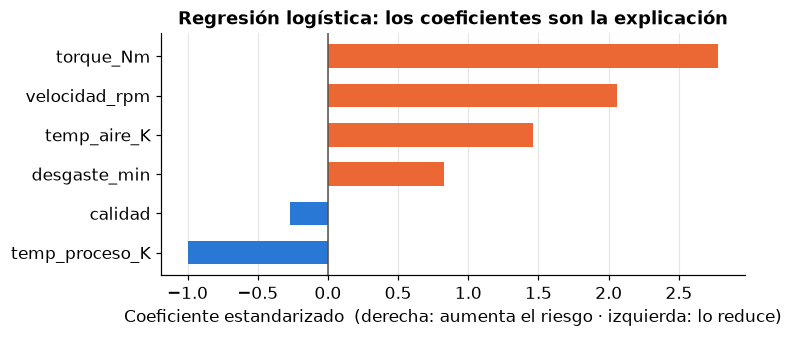

In [9]:
logistica = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logistica.fit(X_entrena, y_entrena)
display(evaluar("Regresión logística", logistica, X_prueba, interpretable=True))

# La "explicación" de este modelo son sus coeficientes.
coeficientes = pd.Series(logistica[-1].coef_[0], index=VARIABLES).sort_values()
fig, eje = plt.subplots(figsize=(7, 3.2))
eje.barh(coeficientes.index, coeficientes.values,
         color=[NARANJA if c > 0 else AZUL for c in coeficientes.values], height=0.6)
eje.axvline(0, color=GRIS, lw=1)
eje.set(title="Regresión logística: los coeficientes son la explicación",
        xlabel="Coeficiente estandarizado  (derecha: aumenta el riesgo · izquierda: lo reduce)")
eje.grid(axis="y", visible=False)
plt.tight_layout(); guardar("03_coeficientes_logistica"); plt.show()

> **Cómo leer esto.** La explicación es clarísima («más torque → más riesgo»), pero el modelo **detecta muy pocas fallas** (mira la columna *Fallas detectadas*). ¿Por qué? Porque una regresión logística solo puede sumar efectos individuales: «un poco por el torque, más otro poco por la velocidad». No puede representar que el riesgo depende de una **combinación** de variables. Una explicación perfecta de un modelo malo no sirve de mucho.

### 3.3 Árbol de decisión pequeño

,¿Se lee directamente?,Precisión,Sensibilidad,F1,PR-AUC,Fallas detectadas,Falsas alarmas
Modelo,,,,,,,
Árbol de decisión (profundidad 3),Sí,0.8,0.188,0.305,0.273,16 de 85,4


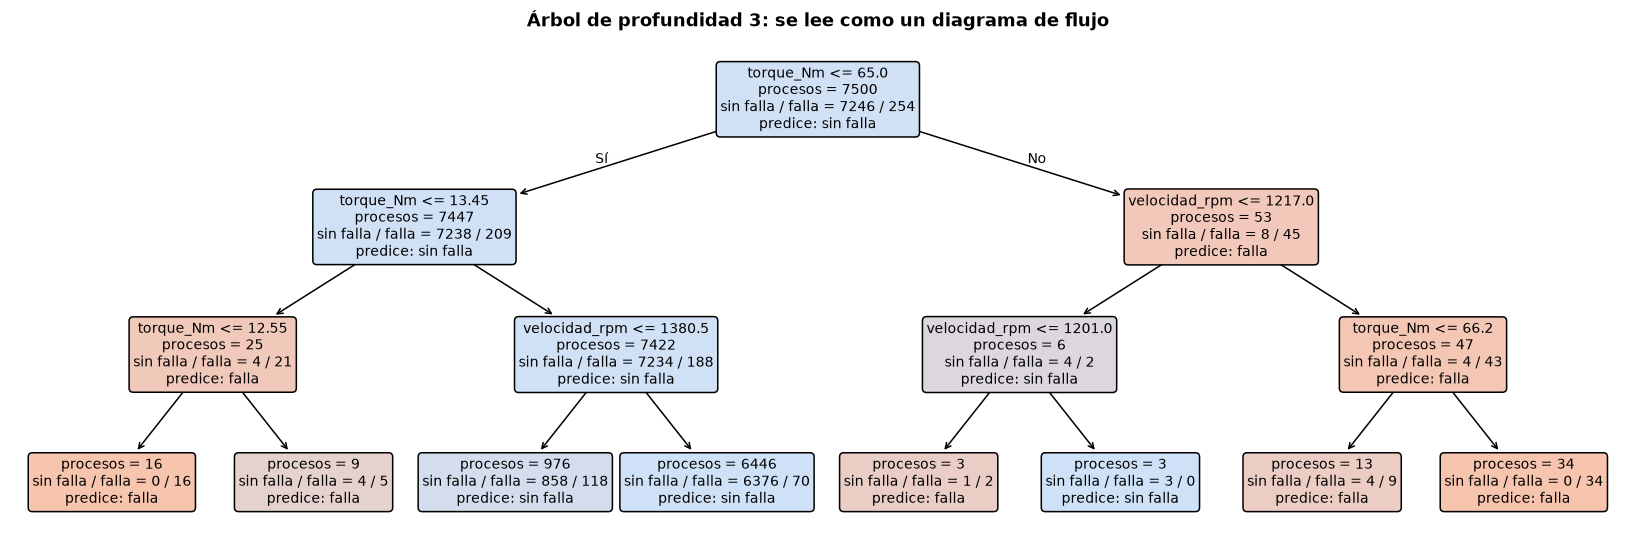

In [10]:
arbol_simple = DecisionTreeClassifier(max_depth=3, random_state=SEMILLA)
arbol_simple.fit(X_entrena, y_entrena)
display(evaluar("Árbol de decisión (profundidad 3)", arbol_simple, X_prueba, interpretable=True))

fig, eje = plt.subplots(figsize=(15, 5.2))
dibujar_arbol(arbol_simple, VARIABLES, eje)
eje.set_title("Árbol de profundidad 3: se lee como un diagrama de flujo")
plt.tight_layout(); guardar("04_arbol_simple"); plt.show()

> **Cómo leer esto.** Cada caja es una pregunta; si la respuesta es «sí» se baja por la rama izquierda. El color indica qué predomina en esa caja: azul para «sin falla» y naranja para «falla». El árbol es totalmente legible, pero con tres niveles solo captura una parte pequeña de las fallas.
>
> **Conclusión de la sección.** Los dos modelos transparentes son fáciles de explicar y poco útiles. Esta es la tensión clásica entre **interpretabilidad y desempeño**, y es la razón por la que existen los modelos de caja negra.

<a id="s4"></a>
## 4. La caja negra: XGBoost

**XGBoost** construye cientos de árboles en secuencia; cada árbol nuevo corrige los errores de los anteriores, y la predicción final es la suma de todos. Suele ser el mejor modelo para datos tabulares, pero nadie puede leer 300 árboles a la vez.

Los hiperparámetros son valores moderados y habituales; el objetivo de este trabajo no es exprimir el desempeño sino **explicar el modelo**.

In [11]:
modelo = XGBClassifier(
    n_estimators=300,        # número de árboles
    max_depth=4,             # profundidad máxima de cada árbol
    learning_rate=0.05,      # cuánto aporta cada árbol nuevo
    subsample=0.8,           # fracción de filas que ve cada árbol (reduce el sobreajuste)
    colsample_bytree=0.8,    # fracción de variables que ve cada árbol
    eval_metric="logloss",
    enable_categorical=False,  # todas las variables son numéricas (necesario para SHAP)
    n_jobs=2,
    random_state=SEMILLA,
)
modelo.fit(X_entrena, y_entrena)

probabilidad_prueba = modelo.predict_proba(X_prueba)[:, 1]
prediccion_prueba = (probabilidad_prueba >= 0.5).astype(int)
display(evaluar("XGBoost (caja negra)", modelo, X_prueba, interpretable=False))

# ¿Qué tan grande es la "caja"?
estructura = modelo.get_booster().trees_to_dataframe()
n_arboles = estructura["Tree"].nunique()
n_reglas = int((estructura["Feature"] != "Leaf").sum())
print(f"El modelo tiene {n_arboles} árboles y {n_reglas:,} reglas de decisión en total.")

,¿Se lee directamente?,Precisión,Sensibilidad,F1,PR-AUC,Fallas detectadas,Falsas alarmas
Modelo,,,,,,,
XGBoost (caja negra),No,0.859,0.647,0.738,0.797,55 de 85,9


El modelo tiene 300 árboles y 3,463 reglas de decisión en total.


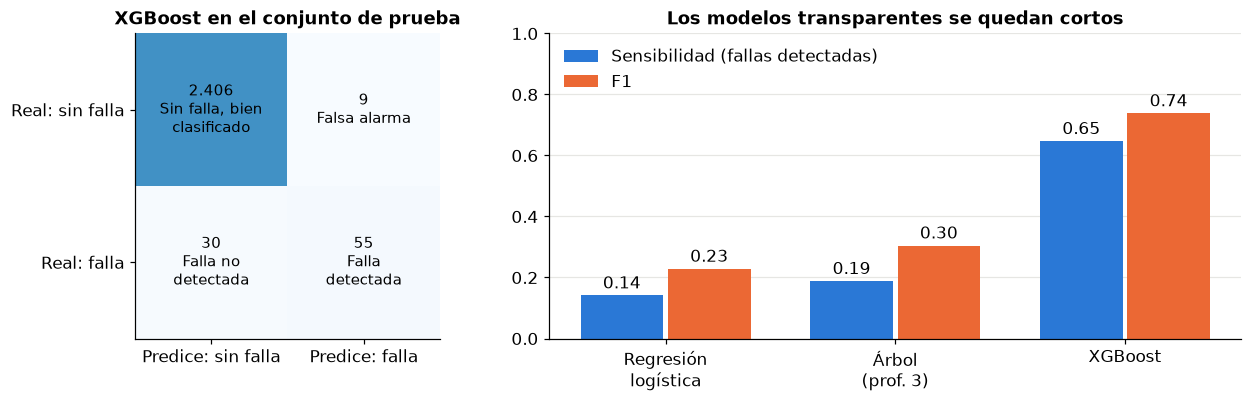

In [12]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1, 1.5]})

# Matriz de confusión del XGBoost.
matriz = confusion_matrix(y_prueba, prediccion_prueba)
ejes[0].imshow(matriz, cmap="Blues", vmin=0, vmax=matriz.max() * 1.6)
etiquetas = [["Sin falla, bien\nclasificado", "Falsa alarma"], ["Falla no\ndetectada", "Falla\ndetectada"]]
for i in range(2):
    for j in range(2):
        ejes[0].text(j, i, f"{miles(matriz[i, j])}\n{etiquetas[i][j]}", ha="center", va="center", fontsize=10)
ejes[0].set_xticks([0, 1], ["Predice: sin falla", "Predice: falla"])
ejes[0].set_yticks([0, 1], ["Real: sin falla", "Real: falla"])
ejes[0].grid(False); ejes[0].set_title("XGBoost en el conjunto de prueba")

# Comparación de los tres modelos.
tabla = pd.DataFrame(resultados).set_index("Modelo")
posiciones = np.arange(len(tabla)); ancho = 0.36
b1 = ejes[1].bar(posiciones - ancho / 2 - 0.01, tabla["Sensibilidad"], ancho, color=AZUL, label="Sensibilidad (fallas detectadas)")
b2 = ejes[1].bar(posiciones + ancho / 2 + 0.01, tabla["F1"], ancho, color=NARANJA, label="F1")
ejes[1].bar_label(b1, fmt="%.2f", padding=2); ejes[1].bar_label(b2, fmt="%.2f", padding=2)
ejes[1].set_xticks(posiciones, ["Regresión\nlogística", "Árbol\n(prof. 3)", "XGBoost"])
ejes[1].set(ylim=(0, 1), title="Los modelos transparentes se quedan cortos")
ejes[1].legend(frameon=False, loc="upper left"); ejes[1].grid(axis="x", visible=False)
plt.tight_layout(); guardar("05_caja_negra_vs_transparentes"); plt.show()

> **Cómo leer esto.** XGBoost detecta 55 de las 85 fallas, más de tres veces las que encontraban los modelos transparentes (12 y 16), con solo 9 falsas alarmas. Pero su «razonamiento» son miles de reglas repartidas en 300 árboles.
>
> Aquí aparece la pregunta central de la exposición: **el modelo funciona, pero ¿por qué dice lo que dice?** Sin esa respuesta, el ingeniero no sabe qué revisar, el gerente no sabe si confiar y nadie puede detectar si el modelo aprendió algo incorrecto.

<a id="s5"></a>
## 5. Explicaciones globales: ¿qué aprendió el modelo en general?

### 5.1 Un mapa de los métodos de XAI

Los métodos se clasifican con tres preguntas:

| Pregunta | Opciones |
|---|---|
| **¿Cuándo se obtiene la explicación?** | *Intrínseca*: el modelo ya es legible (sección 3). *Post-hoc*: se explica un modelo ya entrenado. |
| **¿Qué alcance tiene?** | *Global*: el comportamiento del modelo en general. *Local*: una predicción concreta. |
| **¿Depende del tipo de modelo?** | *Agnóstico*: funciona con cualquier modelo, solo necesita sus predicciones. *Específico*: aprovecha la estructura interna. |

Los cuatro métodos que usamos son todos **post-hoc**:

| Método | Alcance | Tipo | Idea en una frase |
|---|---|---|---|
| Importancia por permutación | Global | Agnóstico | Desordeno una variable y miro cuánto empeora el modelo |
| PDP / ICE | Global / Local | Agnóstico | Muevo una variable y miro cómo cambia la predicción |
| SHAP | Local y global | Agnóstico en teoría; aquí usamos la versión para árboles | Reparto la predicción entre las variables de forma justa |
| LIME | Local | Agnóstico | Ajusto un modelo lineal sencillo alrededor de un caso |

### 5.2 Importancia por permutación

**La idea.** Si una variable es importante, «romperla» debería empeorar el modelo.

**El procedimiento:**
1. Medimos el desempeño del modelo en la prueba (usamos PR-AUC).
2. Tomamos una columna y **barajamos sus valores** entre las filas. Así la columna conserva su distribución pero pierde su relación con la falla.
3. Volvemos a medir. La caída en el desempeño es la importancia de esa variable.
4. Repetimos el barajado 30 veces para tener un promedio y una medida de variabilidad.

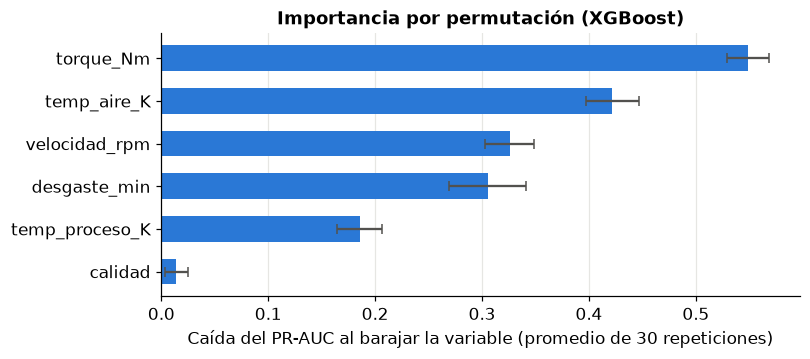

,Caída del PR-AUC
torque_Nm,0.549
temp_aire_K,0.422
velocidad_rpm,0.326
desgaste_min,0.305
temp_proceso_K,0.185
calidad,0.014


In [13]:
permutacion = permutation_importance(
    modelo, X_prueba, y_prueba, scoring="average_precision",
    n_repeats=30, random_state=SEMILLA)

orden = np.argsort(permutacion.importances_mean)
fig, eje = plt.subplots(figsize=(7.5, 3.4))
eje.barh(np.array(VARIABLES)[orden], permutacion.importances_mean[orden],
         xerr=permutacion.importances_std[orden], color=AZUL, height=0.6,
         error_kw={"ecolor": GRIS, "capsize": 3})
eje.set(title="Importancia por permutación (XGBoost)",
        xlabel="Caída del PR-AUC al barajar la variable (promedio de 30 repeticiones)")
eje.grid(axis="y", visible=False)
plt.tight_layout(); guardar("06_importancia_permutacion"); plt.show()

pd.Series(permutacion.importances_mean, index=VARIABLES).sort_values(ascending=False).round(3).to_frame("Caída del PR-AUC")

> **Cómo leer esto.** Barras más largas significan que el modelo depende más de esa variable. El **torque** es la variable de la que más depende el modelo, seguido por la temperatura del aire, la velocidad y el desgaste. La **calidad** del producto casi no influye.
>
> **Limitación.** Este método dice *cuánto* importa cada variable, pero no *en qué dirección* ni *a partir de qué valor*. Para eso necesitamos las siguientes técnicas.

### 5.3 Gráficos de dependencia parcial (PDP) y curvas ICE

**La idea.** Queremos ver cómo cambia la predicción cuando movemos **una sola variable** y dejamos las demás quietas.

- **Curva ICE** (*Individual Conditional Expectation*): tomamos **una máquina**, le cambiamos el torque desde el mínimo hasta el máximo y graficamos la probabilidad de falla en cada punto. Es una curva por máquina.
- **PDP** (*Partial Dependence Plot*): es el **promedio** de todas las curvas ICE. Muestra el efecto medio de la variable.

Graficar las dos juntas es importante: si todas las curvas ICE tienen la misma forma, el promedio las representa bien. Si son muy distintas entre sí, es señal de que la variable **interactúa** con otras.

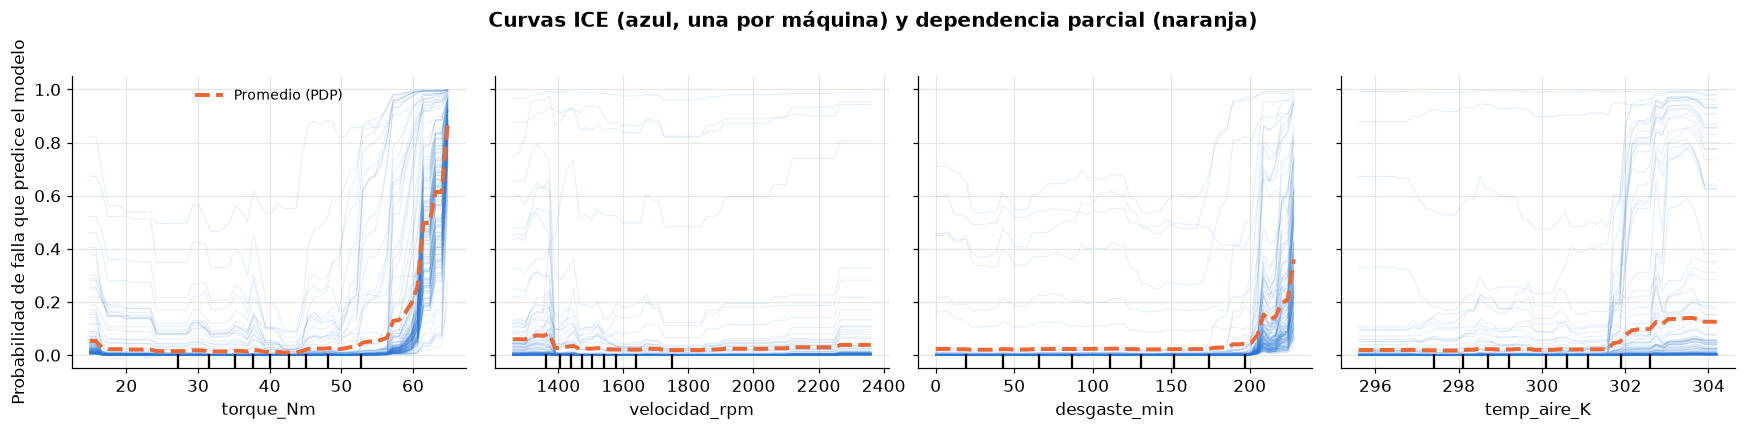

In [14]:
variables_pdp = ["torque_Nm", "velocidad_rpm", "desgaste_min", "temp_aire_K"]

fig, ejes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
PartialDependenceDisplay.from_estimator(
    modelo, X_prueba, variables_pdp, kind="both",          # "both" = ICE + PDP
    percentiles=(0.005, 0.995), grid_resolution=60,        # recorremos casi todo el rango, incluidos los extremos
    subsample=150, random_state=SEMILLA, ax=ejes,
    ice_lines_kw={"color": AZUL, "alpha": 0.12, "linewidth": 0.7},
    pd_line_kw={"color": NARANJA, "linewidth": 2.6, "label": "Promedio (PDP)"})
for eje in ejes:
    eje.set_ylabel("")
    if eje.get_legend():
        eje.get_legend().remove()
ejes[0].legend(frameon=False, fontsize=9, loc="upper center")
ejes[0].set_ylabel("Probabilidad de falla que predice el modelo")
fig.suptitle("Curvas ICE (azul, una por máquina) y dependencia parcial (naranja)", fontweight="bold", y=1.02)
plt.tight_layout(); guardar("07_pdp_ice"); plt.show()

> **Cómo leer esto.**
> - **Torque:** el riesgo es bajo y plano en la zona central y se dispara por encima de unos 55 Nm. En el extremo izquierdo (torque muy bajo) varias curvas individuales también suben, aunque el promedio casi no lo refleja.
> - **Velocidad:** el riesgo sube por debajo de unas 1.380 rpm.
> - **Desgaste:** el riesgo se mantiene plano y sube de golpe al pasar de unos 200 minutos.
> - **Temperatura del aire:** aparece un escalón a partir de unos 302 K.
> - **Las curvas azules son muy distintas entre sí.** Para algunas máquinas el torque alto dispara el riesgo a casi 1 y para otras apenas lo mueve. Eso indica **interacciones**: el efecto de una variable depende del valor de las otras. El promedio (naranja) esconde esa diferencia, y por eso conviene mostrar siempre las curvas ICE junto al PDP.
>
> **Limitación.** Al mover una variable y dejar las demás fijas se crean combinaciones que pueden no existir en la realidad (por ejemplo, torque muy alto con velocidad muy alta). Volveremos sobre esto en la sección 8.

### 5.4 SHAP: repartir la predicción de forma justa

#### La intuición

SHAP (*SHapley Additive exPlanations*) viene de la **teoría de juegos cooperativos**. La analogía:

- El **juego** es hacer una predicción para una máquina.
- Los **jugadores** son las variables (torque, velocidad, etc.).
- El **premio** es la diferencia entre la predicción para esa máquina y la predicción promedio.

La pregunta es: **¿cuánto del premio le corresponde a cada jugador?** No basta con quitar un jugador y ver qué pasa, porque el aporte de cada uno depende de quién más está en el equipo (el torque importa de forma distinta según la velocidad). La solución de Shapley (1953) es promediar el aporte de cada jugador sobre **todas las coaliciones posibles**.

#### La fórmula

El valor de Shapley de la variable $j$ es:

$$\phi_j \;=\; \sum_{S \subseteq N \setminus \{j\}} \frac{|S|!\,(n-|S|-1)!}{n!}\;\Big[\,v(S \cup \{j\}) - v(S)\,\Big]$$

- $N$ es el conjunto de las $n$ variables y $S$ es una coalición (un subconjunto) que no incluye a $j$.
- $v(S)$ es **la predicción promedio del modelo cuando solo conocemos las variables de $S$**. Las variables que no están en $S$ se reemplazan por valores tomados de un conjunto de referencia (máquinas típicas).
- El corchete es el **aporte marginal** de $j$: cuánto cambia la predicción al añadir $j$ a la coalición.
- La fracción es el **peso** de esa coalición: la probabilidad de que $S$ sea exactamente el grupo que llegó antes que $j$ si las variables entraran en orden aleatorio.

#### Por qué es «justo»: cuatro propiedades

| Propiedad | Qué garantiza |
|---|---|
| **Eficiencia** | Los valores suman exactamente la diferencia entre la predicción y el promedio: $\sum_j \phi_j = f(x) - E[f(X)]$ |
| **Simetría** | Dos variables que aportan lo mismo reciben lo mismo |
| **Jugador nulo** | Una variable que no cambia nada recibe cero |
| **Aditividad** | La explicación de una suma de modelos es la suma de las explicaciones |

Los valores de Shapley son la **única** forma de repartir que cumple las cuatro a la vez. Ese respaldo teórico es lo que distingue a SHAP de otros métodos.

#### 5.4.1 Shapley «a mano» para una máquina

Para comprobar que entendemos la fórmula, la programamos directamente y comparamos con la librería. Con 6 variables hay $2^6 = 64$ coaliciones, así que el cálculo exacto es posible. (Con 50 variables serían $10^{15}$; por eso la librería usa el algoritmo **TreeSHAP**, que aprovecha la estructura de los árboles para obtener el mismo resultado en una fracción del tiempo.)

Trabajamos en la escala interna del modelo, los ***log-odds***: $\text{log-odds} = \ln\frac{p}{1-p}$. Es la escala en la que XGBoost suma sus árboles, y se convierte a probabilidad con la función sigmoide $p = \frac{1}{1+e^{-\text{log-odds}}}$.

In [15]:
# Conjunto de referencia: 200 máquinas del entrenamiento que representan "lo típico".
referencia = X_entrena.sample(200, random_state=SEMILLA)

def log_odds(matriz):
    # Predicción del modelo en log-odds para una matriz de máquinas.
    return modelo.predict(pd.DataFrame(matriz, columns=VARIABLES), output_margin=True)

def sigmoide(z):
    return 1 / (1 + np.exp(-z))

def shapley_a_mano(x, referencia):
    # Valores de Shapley exactos de la máquina x, recorriendo todas las coaliciones.
    n = len(x)
    cache = {}

    def v(S):
        # Valor de la coalición S: predicción promedio cuando SOLO fijamos las variables de S
        # en los valores de la máquina x; el resto toma los valores de las máquinas de referencia.
        if S not in cache:
            mezcla = referencia.copy()
            mezcla[:, list(S)] = x[list(S)]
            cache[S] = log_odds(mezcla).mean()
        return cache[S]

    phi = np.zeros(n)
    for j in range(n):                                   # para cada variable j
        otras = [k for k in range(n) if k != j]
        for tamano in range(n):                          # coaliciones de 0, 1, ..., n-1 variables
            peso = math.factorial(tamano) * math.factorial(n - tamano - 1) / math.factorial(n)
            for S in itertools.combinations(otras, tamano):
                aporte_marginal = v(tuple(sorted(S + (j,)))) - v(S)
                phi[j] += peso * aporte_marginal
    return phi, v(()), v(tuple(range(n)))                # valores, predicción base, predicción de x

# Elegimos una máquina concreta: la primera falla de potencia que el modelo detectó en la prueba.
es_falla_detectada = (prediccion_prueba == 1) & (y_prueba.values == 1)
pos_potencia = int(np.where((prueba_original["PWF"].values == 1) & es_falla_detectada)[0][0])
maquina = X_prueba.iloc[pos_potencia]

phi_mano, base, prediccion_x = shapley_a_mano(maquina.values, referencia.values)
print("Máquina analizada:"); display(maquina.to_frame("valor").T)
print(f"Predicción base (promedio de la referencia): {base:+.3f} log-odds -> probabilidad {sigmoide(base):.2%}")
print(f"Predicción para esta máquina:                {prediccion_x:+.3f} log-odds -> probabilidad {sigmoide(prediccion_x):.2%}")

Máquina analizada:


,calidad,temp_aire_K,temp_proceso_K,velocidad_rpm,torque_Nm,desgaste_min
valor,1.0,298.7,310.1,1402.0,69.7,64.0


Predicción base (promedio de la referencia): -6.217 log-odds -> probabilidad 0.20%
Predicción para esta máquina:                +3.188 log-odds -> probabilidad 96.04%


Ahora la misma máquina con la librería `shap`. Usamos `TreeExplainer` con el mismo conjunto de referencia. Este explicador devuelve, para cada máquina y cada variable, un valor SHAP en log-odds.

In [16]:
explicador = shap.TreeExplainer(
    modelo,
    data=shap.maskers.Independent(referencia, max_samples=len(referencia)),
    feature_perturbation="interventional")       # misma definición de v(S) que usamos a mano

# Valores SHAP de todas las máquinas de prueba (tarda alrededor de medio minuto).
valores_shap = explicador(X_prueba)

comparacion = pd.DataFrame({
    "Valor de la máquina": maquina.values,
    "Shapley a mano": phi_mano,
    "Librería shap": valores_shap.values[pos_potencia],
}, index=VARIABLES)
comparacion["Diferencia"] = (comparacion["Shapley a mano"] - comparacion["Librería shap"]).abs()
display(comparacion.round(4))

print(f"Diferencia máxima entre ambos cálculos: {comparacion['Diferencia'].max():.1e}")
print(f"Eficiencia: base + suma de valores = {base + phi_mano.sum():+.3f}  |  predicción = {prediccion_x:+.3f}")

,Valor de la máquina,Shapley a mano,Librería shap,Diferencia
calidad,1.0,-0.0782,-0.0782,0.0
temp_aire_K,298.7,0.0271,0.0271,0.0
temp_proceso_K,310.1,0.0104,0.0104,0.0
velocidad_rpm,1402.0,0.6017,0.6017,0.0
torque_Nm,69.7,9.3385,9.3385,0.0
desgaste_min,64.0,-0.4944,-0.4944,0.0


Diferencia máxima entre ambos cálculos: 1.1e-06
Eficiencia: base + suma de valores = +3.188  |  predicción = +3.188


> **Cómo leer esto.**
> - Los dos cálculos **coinciden** (la diferencia es error numérico de redondeo). La librería no hace magia: aplica la misma fórmula con un algoritmo más rápido.
> - Se cumple la **eficiencia**: la predicción base más la suma de los valores SHAP da exactamente la predicción del modelo.
> - Para esta máquina, casi todo el riesgo viene del **torque**. Un valor positivo empuja hacia «falla»; uno negativo, hacia «sin falla».

#### 5.4.2 SHAP global: resumen de todas las máquinas

Si calculamos los valores SHAP de las 2.500 máquinas de prueba y los miramos juntos, obtenemos una explicación global construida a partir de explicaciones locales.

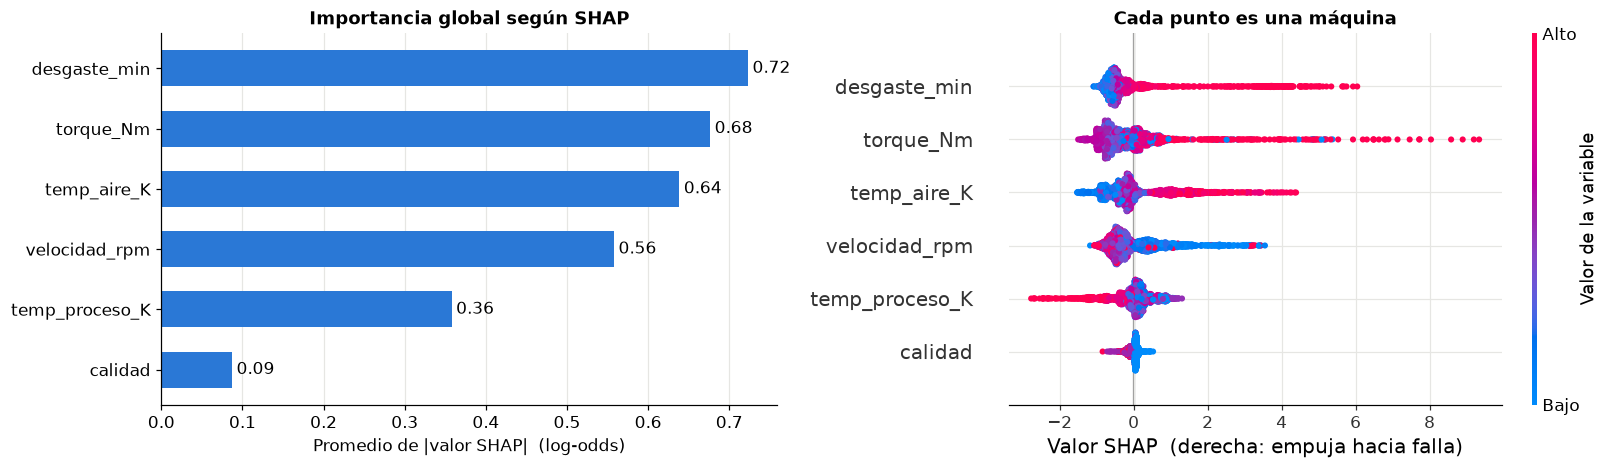

In [17]:
fig = plt.figure(figsize=(15, 4.4))

# Izquierda: importancia global = promedio del valor absoluto de SHAP.
eje_1 = fig.add_subplot(1, 2, 1)
importancia_shap = pd.Series(np.abs(valores_shap.values).mean(axis=0), index=VARIABLES).sort_values()
barras = eje_1.barh(importancia_shap.index, importancia_shap.values, color=AZUL, height=0.6)
eje_1.bar_label(barras, fmt="%.2f", padding=3)
eje_1.set(title="Importancia global según SHAP", xlabel="Promedio de |valor SHAP|  (log-odds)")
eje_1.grid(axis="y", visible=False)

# Derecha: gráfico de enjambre (beeswarm), un punto por máquina y variable.
eje_2 = fig.add_subplot(1, 2, 2)
shap.plots.beeswarm(valores_shap, show=False, plot_size=None, ax=eje_2, color_bar_label="Valor de la variable")
eje_2.set_title("Cada punto es una máquina"); eje_2.set_xlabel("Valor SHAP  (derecha: empuja hacia falla)")
fig.axes[-1].set_yticklabels(["Bajo", "Alto"])                 # la barra de color viene en inglés
plt.tight_layout(); guardar("08_shap_global"); plt.show()

> **Cómo leer el gráfico de enjambre (derecha).**
> - Cada fila es una variable; cada punto, una máquina.
> - La **posición horizontal** es el valor SHAP: a la derecha empuja hacia «falla», a la izquierda hacia «sin falla».
> - El **color** es el valor de la variable para esa máquina: rojo es alto, azul es bajo.
>
> Con esas tres claves se lee mucho más que en un gráfico de barras:
> - **Desgaste:** solo los puntos rojos (desgaste alto) empujan hacia falla.
> - **Torque:** los valores más extremos a la derecha son rojos (torque alto), pero también hay puntos azules (torque bajo) con valor positivo. Los dos extremos del torque son peligrosos.
> - **Velocidad:** los puntos azules (velocidad baja) empujan hacia falla.
> - **Temperatura del aire alta** empuja hacia falla, pero **temperatura del proceso alta** empuja hacia «sin falla». Es extraño que dos temperaturas que se mueven juntas actúen en sentidos opuestos. Lo aclaramos en la sección 8.
>
> **Un detalle de rigor.** El orden de importancia no coincide exactamente con el de permutación (allá el torque era primero; aquí lo es el desgaste). No es un error: miden cosas distintas. Permutación mide cuánto **empeora el desempeño** al perder la variable; SHAP mide cuánto **mueve las predicciones**. Conviene mirar más de un método antes de afirmar «la variable más importante es X».

#### 5.4.3 Gráfico de dependencia SHAP

Graficamos el valor SHAP de una variable contra el valor de esa variable. Es parecido al PDP, pero con una diferencia: aquí cada punto es una máquina real, no un promedio. El color muestra una segunda variable.

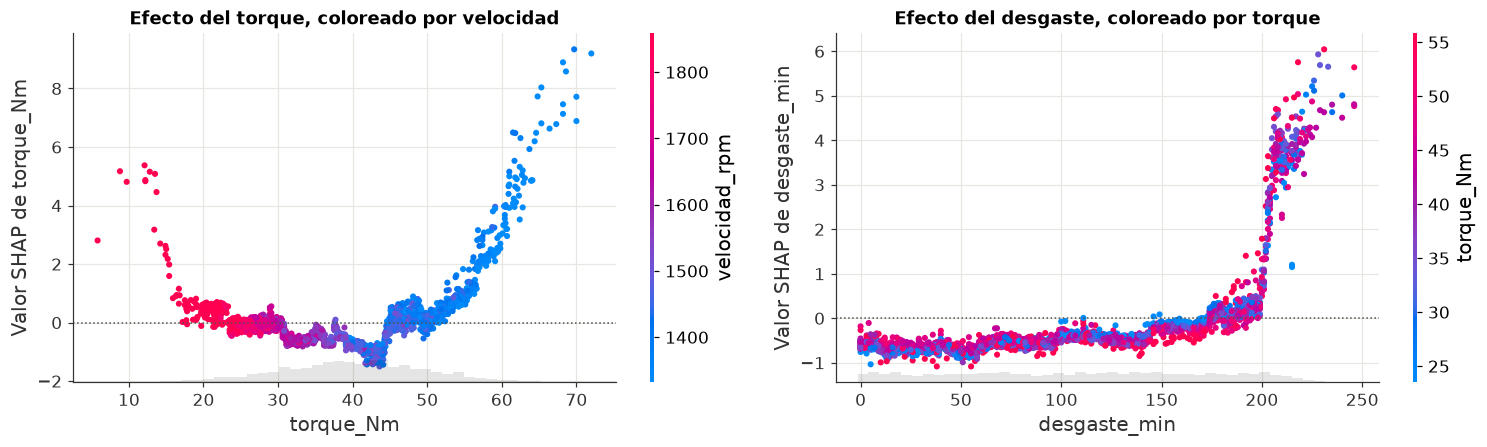

In [18]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.2))
shap.plots.scatter(valores_shap[:, "torque_Nm"], color=valores_shap[:, "velocidad_rpm"], ax=ejes[0], show=False)
ejes[0].set_title("Efecto del torque, coloreado por velocidad")
shap.plots.scatter(valores_shap[:, "desgaste_min"], color=valores_shap[:, "torque_Nm"], ax=ejes[1], show=False)
ejes[1].set_title("Efecto del desgaste, coloreado por torque")
for eje, variable in zip(ejes, ["torque_Nm", "desgaste_min"]):
    eje.axhline(0, color=GRIS, lw=1, ls=":"); eje.set_ylabel(f"Valor SHAP de {variable}")
plt.tight_layout(); guardar("09_shap_dependencia"); plt.show()

> **Cómo leer esto.**
> - **Izquierda:** el efecto del torque tiene forma de **U**. Por debajo de unos 15 Nm y por encima de unos 50 Nm el valor SHAP es positivo. Los puntos de torque bajo son rojos (velocidad alta) y los de torque alto son azules (velocidad baja): como las dos variables están ligadas, este gráfico por sí solo no permite separar el papel de cada una. Hay que mirarlas **en pareja**.
> - **Derecha:** el efecto del desgaste es plano hasta unos 200 minutos y luego salta. Para un mismo desgaste, los puntos quedan a alturas distintas: el efecto del desgaste depende de algo más.

#### 5.4.4 ¿Qué variables actúan en pareja? Valores de interacción SHAP

SHAP permite descomponer cada valor en un **efecto propio** de la variable y **efectos de interacción** con cada una de las demás. Si sumamos la magnitud de esas interacciones sobre todas las máquinas, obtenemos qué parejas de variables usa el modelo de forma conjunta.

(Los valores de interacción solo están disponibles en la variante de TreeSHAP que no usa conjunto de referencia, así que aquí usamos el explicador por defecto. Es un cálculo rápido.)

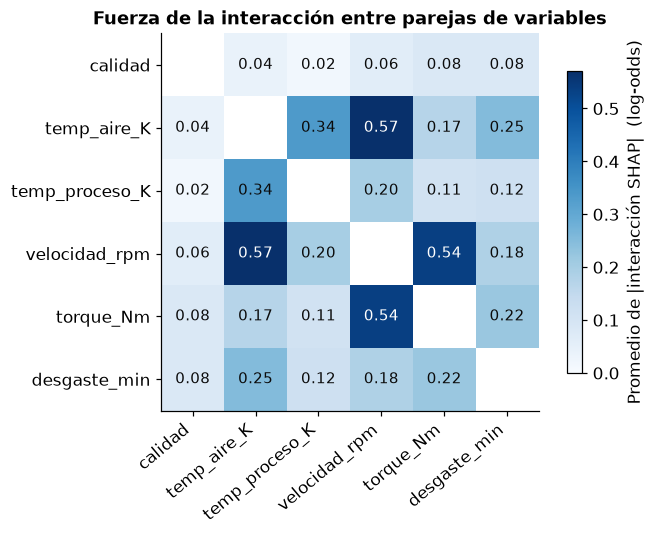

,Fuerza de la interacción
Pareja,
temp_aire_K × velocidad_rpm,0.571
velocidad_rpm × torque_Nm,0.536
temp_aire_K × temp_proceso_K,0.336
temp_aire_K × desgaste_min,0.252
torque_Nm × desgaste_min,0.219


In [19]:
# Tensor de tamaño (máquinas, variables, variables): la diagonal son efectos propios; fuera de ella, interacciones.
interacciones = shap.TreeExplainer(modelo).shap_interaction_values(X_prueba)

fuerza = 2 * np.abs(interacciones).mean(axis=0)        # se multiplica por 2 porque cada pareja aparece dos veces
np.fill_diagonal(fuerza, np.nan)                        # ocultamos los efectos propios para ver solo las parejas

fig, eje = plt.subplots(figsize=(6.6, 5))
imagen = eje.imshow(fuerza, cmap="Blues", vmin=0)
eje.set_xticks(range(len(VARIABLES)), VARIABLES, rotation=40, ha="right")
eje.set_yticks(range(len(VARIABLES)), VARIABLES)
for i in range(len(VARIABLES)):
    for j in range(len(VARIABLES)):
        if i != j:
            eje.text(j, i, f"{fuerza[i, j]:.2f}", ha="center", va="center", fontsize=10,
                     color="white" if fuerza[i, j] > 0.35 else "#0b0b0b")
eje.grid(False); eje.set_title("Fuerza de la interacción entre parejas de variables")
plt.colorbar(imagen, ax=eje, shrink=0.8, label="Promedio de |interacción SHAP|  (log-odds)")
plt.tight_layout(); guardar("09b_shap_interacciones"); plt.show()

parejas = pd.DataFrame([{"Pareja": f"{VARIABLES[i]}  ×  {VARIABLES[j]}", "Fuerza de la interacción": fuerza[i, j]}
                        for i in range(len(VARIABLES)) for j in range(i + 1, len(VARIABLES))])
parejas.sort_values("Fuerza de la interacción", ascending=False).head(5).set_index("Pareja").round(3)

> **Cómo leer esto.** Las celdas más oscuras son las parejas que el modelo usa de forma conjunta. Las cinco más fuertes son:
>
> 1. **Temperatura del aire × velocidad**
> 2. **Velocidad × torque**
> 3. **Temperatura del aire × temperatura del proceso**
> 4. Temperatura del aire × desgaste
> 5. **Torque × desgaste**
>
> Guardemos esta lista. Un ingeniero mecánico reconoce varias de inmediato: velocidad × torque es la **potencia**; dos temperaturas que actúan juntas sugieren una **diferencia de temperatura**; torque × desgaste es la **carga acumulada sobre la herramienta**. En la [sección 7](#s7) veremos cuáles corresponden a mecanismos reales.

<a id="s6"></a>
## 6. Explicaciones locales: ¿por qué *esta* máquina?

Las explicaciones globales describen al modelo. Pero el ingeniero de turno tiene una alerta sobre **una máquina concreta** y necesita saber qué revisar.

Elegimos tres máquinas de la prueba en las que el modelo acertó al predecir falla. Para no escoger a conveniencia, tomamos **la primera falla detectada de cada tipo** según el orden del conjunto de prueba. El modelo nunca vio el tipo de falla.

In [20]:
def primera_falla_detectada(modo):
    # Posición (en la prueba) de la primera falla de ese tipo que el modelo detectó.
    return int(np.where((prueba_original[modo].values == 1) & es_falla_detectada)[0][0])

casos = {modo: primera_falla_detectada(modo) for modo in ["PWF", "OSF", "HDF"]}

resumen_casos = X_prueba.iloc[list(casos.values())].copy()
resumen_casos.insert(0, "Tipo real de falla (oculto al modelo)", [f"{NOMBRE_MODO[m]} ({m})" for m in casos])
resumen_casos["Probabilidad que da el modelo"] = probabilidad_prueba[list(casos.values())].round(3)
resumen_casos.index = [f"Máquina {letra}" for letra in "ABC"]
resumen_casos

,Tipo real de falla (oculto al modelo),calidad,temp_aire_K,temp_proceso_K,velocidad_rpm,torque_Nm,desgaste_min,Probabilidad que da el modelo
Máquina A,Potencia (PWF),1.0,298.7,310.1,1402.0,69.7,64.0,0.960
Máquina B,Sobrecarga (OSF),0.0,297.7,308.5,1373.0,56.7,203.0,0.724
Máquina C,Disipación de calor (HDF),0.0,303.3,311.3,1350.0,48.1,32.0,0.843


### 6.1 SHAP local: gráfico de cascada

El gráfico de cascada muestra cómo se construye una predicción paso a paso:

- Empieza **abajo** en la predicción base $E[f(X)]$: lo que el modelo predice para una máquina típica.
- Cada barra es una variable: **roja** si empuja hacia falla, **azul** si empuja en contra. El número gris a la izquierda es el valor de la variable en esa máquina.
- Termina **arriba** en $f(x)$: la predicción para esta máquina.

Todo está en log-odds; en el título convertimos el resultado a probabilidad.

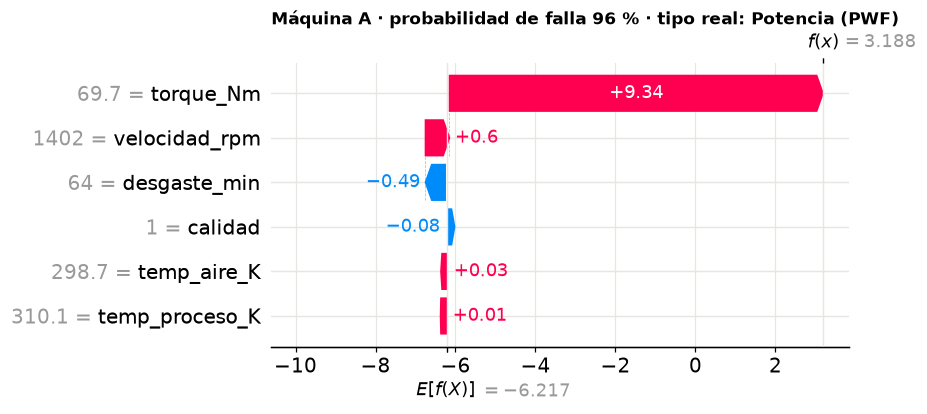

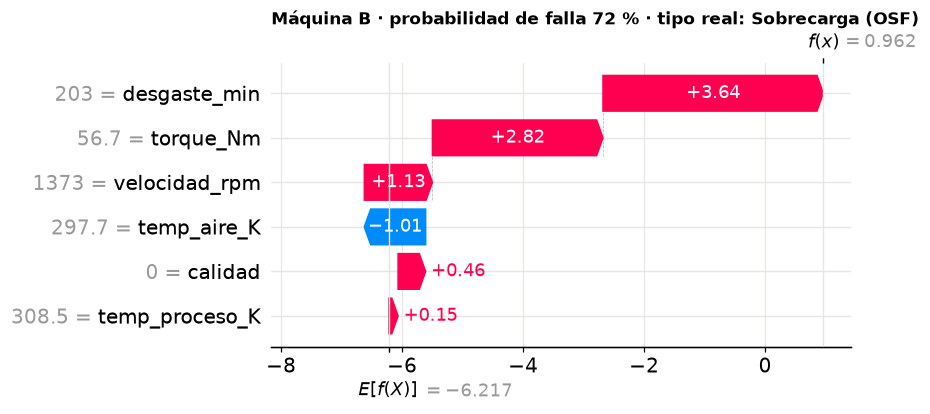

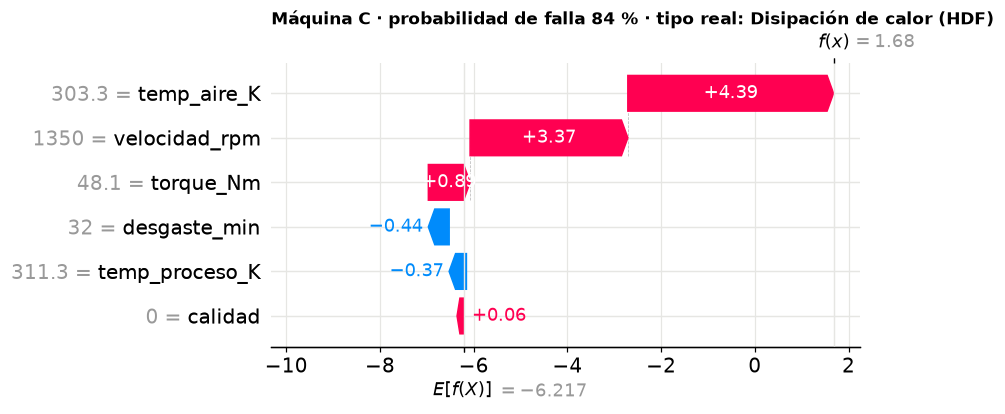

In [21]:
def cascada(posicion, titulo, nombre_archivo):
    # Gráfico de cascada de SHAP para una máquina de la prueba.
    shap.plots.waterfall(valores_shap[posicion], show=False)
    figura = plt.gcf(); figura.set_size_inches(8.5, 3.9)
    # Dejamos margen a la izquierda para que las etiquetas negativas no tapen los nombres.
    minimo, maximo = figura.axes[0].get_xlim()
    for eje in figura.axes:
        eje.set_xlim(minimo - 0.18 * (maximo - minimo), maximo)
    figura.axes[0].set_title(titulo, fontsize=11, loc="left")
    plt.tight_layout(); guardar(nombre_archivo); plt.show()

for letra, (modo, pos) in zip("ABC", casos.items()):
    cascada(pos, f"Máquina {letra} · probabilidad de falla {porcentaje(probabilidad_prueba[pos])} · "
                 f"tipo real: {NOMBRE_MODO[modo]} ({modo})", f"10{letra.lower()}_shap_cascada_maquina_{letra}")

> **Cómo leer esto.** Las tres alertas dicen lo mismo («va a fallar») pero por **razones distintas**, y cada explicación apunta a una acción diferente:
>
> | Máquina | Qué señala SHAP | Qué revisaría el ingeniero |
> |---|---|---|
> | A | Torque muy alto, con velocidad baja | La carga del proceso: se está exigiendo demasiada potencia |
> | B | Desgaste alto junto con torque alto | La herramienta: cambiarla antes de seguir cargándola |
> | C | Temperatura del aire alta y velocidad baja | La refrigeración: el calor no se está disipando |
>
> Esta es la utilidad práctica de XAI: convierte una probabilidad en una **orden de trabajo**.

### 6.2 LIME: un modelo sencillo alrededor de un caso

LIME (*Local Interpretable Model-agnostic Explanations*) parte de otra idea: aunque el modelo sea muy complejo en general, **cerca de un punto concreto** se puede aproximar con algo sencillo.

**El procedimiento:**
1. Tomamos la máquina que queremos explicar.
2. Generamos miles de máquinas **ficticias parecidas**, alterando sus valores al azar.
3. Le pedimos al modelo de caja negra la predicción para cada una.
4. Damos **más peso** a las ficticias que quedaron más cerca de la máquina original.
5. Ajustamos una **regresión lineal ponderada** sobre esas predicciones. Sus coeficientes son la explicación.

Explicamos la **máquina A** para compararla con SHAP.

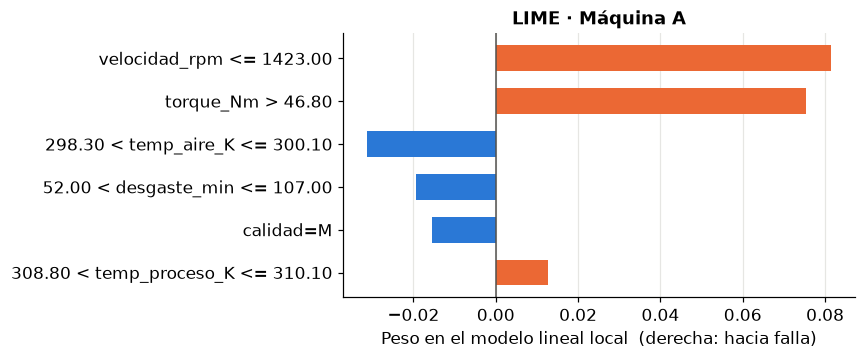

In [22]:
def probabilidades(matriz):
    # Función que LIME usa para consultar al modelo.
    return modelo.predict_proba(pd.DataFrame(matriz, columns=VARIABLES))

def explicador_lime(semilla):
    return LimeTabularExplainer(
        X_entrena.values, feature_names=VARIABLES, class_names=["sin falla", "falla"],
        categorical_features=[0], categorical_names={0: ["L", "M", "H"]},
        mode="classification", discretize_continuous=True, random_state=semilla)

pos_A = casos["PWF"]
explicacion_lime = explicador_lime(SEMILLA).explain_instance(
    X_prueba.values[pos_A], probabilidades, num_features=6, num_samples=5000)

reglas = pd.DataFrame(explicacion_lime.as_list(), columns=["Regla", "Peso"]).iloc[::-1]
fig, eje = plt.subplots(figsize=(8, 3.4))
eje.barh(reglas["Regla"], reglas["Peso"], color=[NARANJA if p > 0 else AZUL for p in reglas["Peso"]], height=0.6)
eje.axvline(0, color=GRIS, lw=1)
eje.set(title="LIME · Máquina A", xlabel="Peso en el modelo lineal local  (derecha: hacia falla)")
eje.grid(axis="y", visible=False)
plt.tight_layout(); guardar("11_lime_maquina_A"); plt.show()

> **Cómo leer esto.** LIME convierte cada variable en un rango (por ejemplo `torque_Nm > 46.80`) y le asigna un peso. Naranja empuja hacia falla; azul, en contra.

### 6.3 ¿SHAP y LIME dicen lo mismo?

In [23]:
pesos_lime = pd.Series(dict(explicacion_lime.as_map()[1])).rename(index=dict(enumerate(VARIABLES)))

comparacion_metodos = pd.DataFrame({
    "Valor en la máquina A": X_prueba.iloc[pos_A],
    "SHAP (log-odds)": pd.Series(valores_shap.values[pos_A], index=VARIABLES),
    "LIME (peso)": pesos_lime,
})
comparacion_metodos["Puesto SHAP"] = comparacion_metodos["SHAP (log-odds)"].abs().rank(ascending=False).astype(int)
comparacion_metodos["Puesto LIME"] = comparacion_metodos["LIME (peso)"].abs().rank(ascending=False).astype(int)
comparacion_metodos.sort_values("Puesto SHAP").round(3)

,Valor en la máquina A,SHAP (log-odds),LIME (peso),Puesto SHAP,Puesto LIME
torque_Nm,69.7,9.339,0.075,1,2
velocidad_rpm,1402.0,0.602,0.082,2,1
desgaste_min,64.0,-0.494,-0.019,3,4
calidad,1.0,-0.078,-0.015,4,5
temp_aire_K,298.7,0.027,-0.031,5,3
temp_proceso_K,310.1,0.010,0.013,6,6


> **Cómo leer esto.** Los dos métodos coinciden en lo esencial: **torque y velocidad** son las dos variables que explican la alerta de la máquina A. Discrepan en el orden entre ellas y en las variables menores.
>
> Que dos métodos con fundamentos distintos lleguen a la misma conclusión da más confianza que cualquiera de ellos por separado. Pero las unidades **no son comparables**: SHAP reparte la predicción exacta en log-odds y LIME da coeficientes de un modelo aproximado. En la sección 8 veremos qué tan aproximado es.

<a id="s7"></a>
## 7. La prueba de fuego: ¿las explicaciones coinciden con la física?

En un proyecto real nunca sabemos si una explicación es «correcta», porque no conocemos la verdadera causa. Aquí sí la conocemos. Según la documentación del dataset, las fallas se generaron con estas reglas:

| Tipo de falla | Regla física | Variables involucradas |
|---|---|---|
| **Disipación de calor (HDF)** | Diferencia de temperatura (proceso − aire) menor a **8,6 K** *y* velocidad menor a **1.380 rpm** | Las dos temperaturas y la velocidad |
| **Potencia (PWF)** | Potencia $P = \tau \cdot \omega$ menor a **3.500 W** o mayor a **9.000 W** | Torque y velocidad |
| **Sobrecarga (OSF)** | Desgaste × torque mayor a **11.000 / 12.000 / 13.000 min·Nm** según calidad L / M / H | Desgaste, torque (y calidad) |
| **Desgaste de herramienta (TWF)** | La herramienta falla o se reemplaza en un momento **aleatorio** entre 200 y 240 min de desgaste | Desgaste |
| **Aleatoria (RNF)** | 0,1 % de probabilidad, sin importar las variables | Ninguna |

### 7.1 Primero verificamos que las reglas reproducen los datos

No damos por buena la documentación sin comprobarla.

In [24]:
# Magnitudes físicas calculadas con los datos originales.
delta_T = datos["temp_proceso_K"] - datos["temp_aire_K"]                       # K
potencia = datos["torque_Nm"] * datos["velocidad_rpm"] * 2 * np.pi / 60        # W  (rpm -> rad/s)
sobrecarga = datos["desgaste_min"] * datos["torque_Nm"]                        # min·Nm
limite_sobrecarga = datos["Type"].map({"L": 11000, "M": 12000, "H": 13000})

reglas_fisicas = {
    "HDF": (delta_T < 8.6) & (datos["velocidad_rpm"] < 1380),
    "PWF": (potencia < 3500) | (potencia > 9000),
    "OSF": sobrecarga > limite_sobrecarga,
}
pd.DataFrame([{
    "Tipo de falla": f"{NOMBRE_MODO[m]} ({m})",
    "Casos según la regla": int(regla.sum()),
    "Casos en la etiqueta": int(datos[m].sum()),
    "Coincidencia fila a fila": f"{(regla == datos[m].astype(bool)).mean():.1%}",
} for m, regla in reglas_fisicas.items()]).set_index("Tipo de falla")

,Casos según la regla,Casos en la etiqueta,Coincidencia fila a fila
Tipo de falla,,,
Disipación de calor (HDF),115,115,100.0%
Potencia (PWF),95,95,100.0%
Sobrecarga (OSF),98,98,100.0%


> **Cómo leer esto.** Las tres reglas deterministas reproducen las etiquetas al **100 %**, fila por fila. Tenemos una hoja de respuestas confiable.

### 7.2 ¿SHAP señala las variables correctas?

Para cada falla de la prueba sabemos qué variables la causaron. Entonces podemos preguntar: **¿las variables que SHAP pone en primer lugar son las que la física dice?**

Medimos dos cosas por cada tipo de falla (usando solo fallas con un único tipo, para que la respuesta correcta sea inequívoca):
- **Acierto en la principal:** la variable con mayor valor SHAP está entre las causas reales.
- **Acierto en las dos principales:** las dos variables con mayor valor SHAP están *ambas* entre las causas reales.

,Fallas en la prueba,Detectadas por el modelo,Acierto en la principal,Acierto en las dos principales
Tipo de falla,,,,
Disipación de calor (HDF),35,24,89%,80%
Potencia (PWF),15,12,100%,80%
Sobrecarga (OSF),18,16,100%,89%
Desgaste de herramienta (TWF),12,0,92%,92%


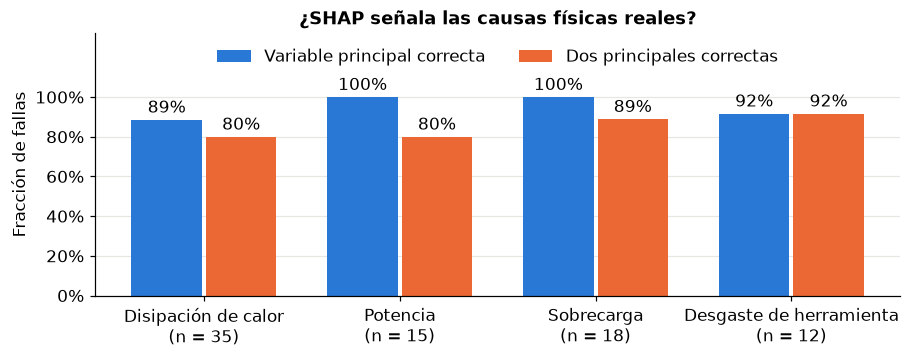

In [25]:
CAUSAS_REALES = {
    "HDF": {"temp_aire_K", "temp_proceso_K", "velocidad_rpm"},
    "PWF": {"torque_Nm", "velocidad_rpm"},
    "OSF": {"desgaste_min", "torque_Nm"},
    "TWF": {"desgaste_min"},
}
nombres = np.array(VARIABLES)
un_solo_modo = prueba_original[["TWF", "HDF", "PWF", "OSF"]].sum(axis=1).values == 1

filas = []
for modo, causas in CAUSAS_REALES.items():
    posiciones = np.where((prueba_original[modo].values == 1) & un_solo_modo)[0]
    k = min(2, len(causas))                                    # TWF solo tiene una causa
    # Variables ordenadas de mayor a menor empuje hacia "falla" para cada máquina.
    ranking = [nombres[np.argsort(-valores_shap.values[p])] for p in posiciones]
    filas.append({
        "Tipo de falla": f"{NOMBRE_MODO[modo]} ({modo})",
        "Fallas en la prueba": len(posiciones),
        "Detectadas por el modelo": int(prediccion_prueba[posiciones].sum()),
        "Acierto en la principal": np.mean([r[0] in causas for r in ranking]),
        f"Acierto en las dos principales": np.mean([set(r[:k]) <= causas for r in ranking]),
    })
validacion = pd.DataFrame(filas).set_index("Tipo de falla")
display(validacion.style.format({"Acierto en la principal": "{:.0%}", "Acierto en las dos principales": "{:.0%}"}))

fig, eje = plt.subplots(figsize=(8.5, 3.4))
pos = np.arange(len(validacion)); ancho = 0.36
b1 = eje.bar(pos - ancho / 2 - 0.01, validacion["Acierto en la principal"], ancho, color=AZUL, label="Variable principal correcta")
b2 = eje.bar(pos + ancho / 2 + 0.01, validacion["Acierto en las dos principales"], ancho, color=NARANJA, label="Dos principales correctas")
eje.bar_label(b1, labels=[f"{v:.0%}" for v in validacion["Acierto en la principal"]], padding=2)
eje.bar_label(b2, labels=[f"{v:.0%}" for v in validacion["Acierto en las dos principales"]], padding=2)
eje.set_xticks(pos, [f"{i.split(' (')[0]}\n(n = {n})" for i, n in zip(validacion.index, validacion["Fallas en la prueba"])])
eje.set(ylim=(0, 1.32), ylabel="Fracción de fallas", title="¿SHAP señala las causas físicas reales?")
eje.set_yticks(np.arange(0, 1.01, 0.2))
eje.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
eje.legend(frameon=False, ncol=2, loc="upper center"); eje.grid(axis="x", visible=False)
plt.tight_layout(); guardar("12_validacion_fisica"); plt.show()

> **Cómo leer esto.** Sin haber visto nunca el tipo de falla ni las reglas, las explicaciones de SHAP apuntan a las variables físicamente correctas en la gran mayoría de los casos: la variable principal acierta entre el 89 % y el 100 % de las veces según el tipo de falla, y las dos principales entre el 80 % y el 92 %.
>
> **Dos advertencias honestas:**
> - Los grupos son pequeños (entre 12 y 35 fallas por tipo), así que estos porcentajes tienen incertidumbre.
> - Mira la fila de **desgaste de herramienta**: SHAP señala bien la variable, pero el modelo **no detectó ninguna** de esas fallas. Una explicación correcta no implica una predicción correcta. Lo retomamos en la sección 8.3.

### 7.3 El mapa de riesgo del modelo contra las fronteras físicas

Una comprobación visual. En cada panel ubicamos las máquinas de prueba según dos variables y las coloreamos con la **suma de los valores SHAP de esas dos variables** (rojo: el modelo considera peligrosa esa combinación). Encima dibujamos, con línea punteada, **la frontera que dicta la física**.

Si el modelo aprendió la física, los puntos rojos deben aparecer justo al otro lado de las líneas.

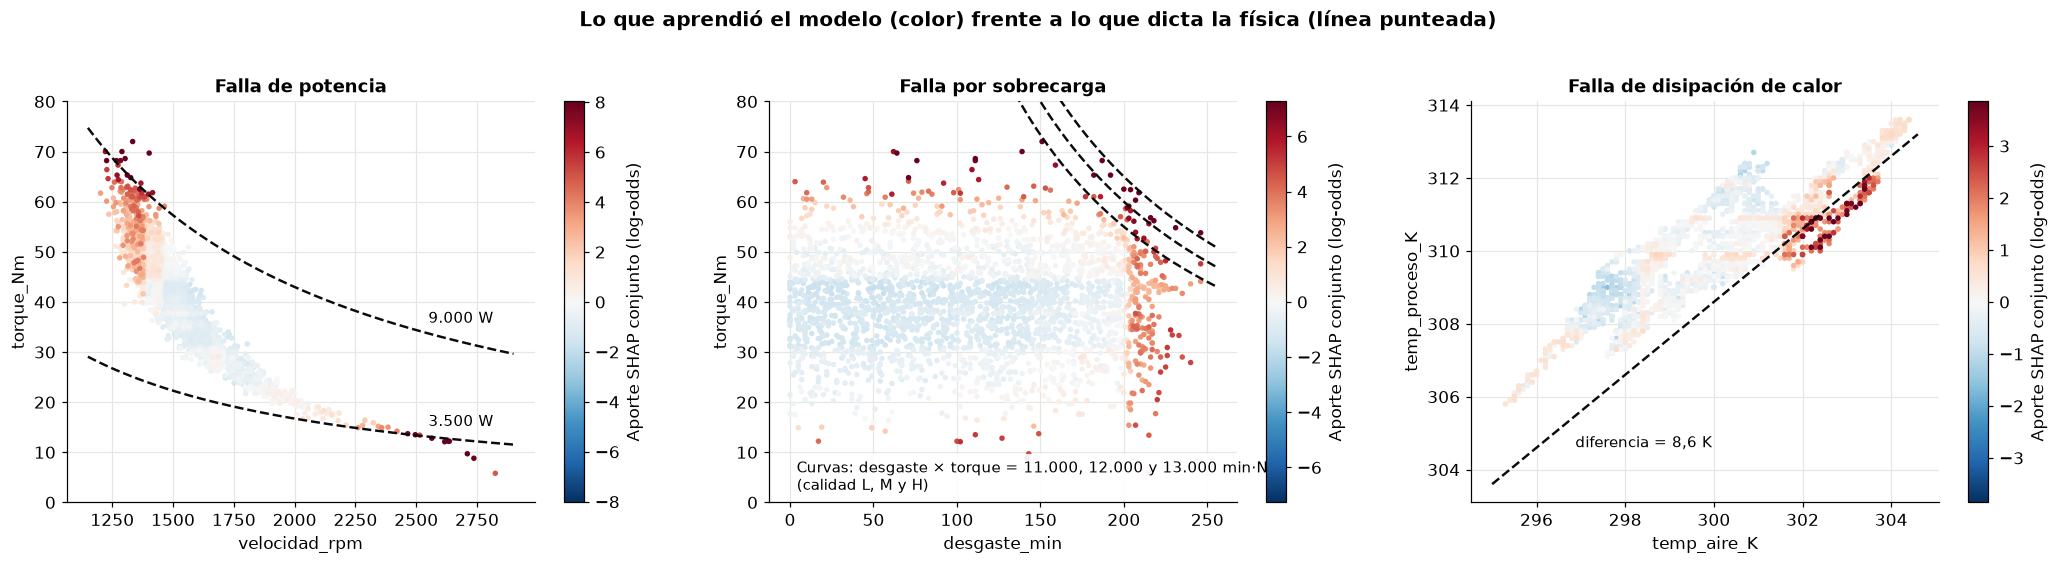

In [26]:
shap_df = pd.DataFrame(valores_shap.values, columns=VARIABLES, index=X_prueba.index)

def panel(eje, var_x, var_y, titulo):
    # Dispersión de las máquinas de prueba coloreada por el aporte SHAP conjunto de las dos variables.
    aporte = shap_df[var_x] + shap_df[var_y]
    orden = np.argsort(aporte.values)                          # los rojos se dibujan al final, encima
    limite = np.abs(aporte).quantile(0.995)
    puntos = eje.scatter(X_prueba[var_x].values[orden], X_prueba[var_y].values[orden], c=aporte.values[orden],
                         cmap="RdBu_r", vmin=-limite, vmax=limite, s=13, linewidths=0)
    plt.colorbar(puntos, ax=eje, label="Aporte SHAP conjunto (log-odds)")
    eje.set(xlabel=var_x, ylabel=var_y, title=titulo)

fig, ejes = plt.subplots(1, 3, figsize=(19, 5))
estilo = dict(color="#0b0b0b", ls="--", lw=1.6)

# Panel 1: potencia. P = torque * velocidad  ->  torque = P / velocidad
panel(ejes[0], "velocidad_rpm", "torque_Nm", "Falla de potencia")
rpm = np.linspace(1150, 2900, 300)
for P, texto in [(9000, "9.000 W"), (3500, "3.500 W")]:
    ejes[0].plot(rpm, P * 60 / (2 * np.pi * rpm), **estilo)
    ejes[0].annotate(texto, (2550, P * 60 / (2 * np.pi * 2550)), xytext=(0, 7), textcoords="offset points", fontsize=10)
ejes[0].set_ylim(0, 80)

# Panel 2: sobrecarga. desgaste * torque = límite  ->  torque = límite / desgaste
panel(ejes[1], "desgaste_min", "torque_Nm", "Falla por sobrecarga")
desgaste = np.linspace(135, 255, 200)
for limite_fisico in (11000, 12000, 13000):
    ejes[1].plot(desgaste, limite_fisico / desgaste, **estilo)
ejes[1].text(4, 2.5, "Curvas: desgaste × torque = 11.000, 12.000 y 13.000 min·Nm\n(calidad L, M y H)", fontsize=9.5,
             bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.9})
ejes[1].set_ylim(0, 80)

# Panel 3: disipación de calor. temp_proceso - temp_aire = 8,6 K
panel(ejes[2], "temp_aire_K", "temp_proceso_K", "Falla de disipación de calor")
aire = np.linspace(295, 304.6, 10)
ejes[2].plot(aire, aire + 8.6, **estilo)
ejes[2].annotate("diferencia = 8,6 K", (296.6, 296.6 + 8.6), xytext=(8, -14), textcoords="offset points", fontsize=10)

fig.suptitle("Lo que aprendió el modelo (color) frente a lo que dicta la física (línea punteada)", fontweight="bold", y=1.02)
plt.tight_layout(); guardar("13_mapa_riesgo_vs_fisica"); plt.show()

> **Cómo leer esto.**
> - **Potencia:** los puntos rojos más intensos aparecen por encima de la curva de 9.000 W y por debajo de la de 3.500 W. El modelo nunca recibió la fórmula $P = \tau\cdot\omega$ y aun así dibujó dos fronteras con forma de hipérbola.
> - **Sobrecarga:** los puntos rojos se concentran al otro lado de las curvas desgaste × torque. Además aparece una franja vertical a partir de 200 min: es la falla por desgaste de herramienta.
> - **Disipación de calor:** los puntos rojos se agrupan junto a la recta y por debajo de ella, donde la diferencia de temperatura es menor a 8,6 K.
>
> **¿Y las parejas de la sección 5.4.4?** De las cinco interacciones más fuertes, cuatro corresponden a un mecanismo real: temperatura del aire × velocidad y temperatura del aire × temperatura del proceso (disipación de calor), velocidad × torque (potencia) y torque × desgaste (sobrecarga). La cuarta de la lista, temperatura del aire × desgaste, no aparece en ninguna regla. Las interacciones son buenas pistas, pero no pruebas.
>
> **Conclusión de la sección.** En este dataset, donde podemos comprobarlo, las explicaciones de SHAP reflejan en gran medida el mecanismo real. Es una buena noticia, pero no es toda la historia.

<a id="s8"></a>
## 8. Riesgos y límites de XAI

Una explicación es un modelo de un modelo, y también puede fallar. En esta sección mostramos **tres riesgos con evidencia de este mismo ejemplo**.

### 8.1 Riesgo 1 — Variables correlacionadas: la explicación es fiel al modelo, pero puede confundir sobre el mecanismo

En el gráfico de enjambre quedó algo raro: la temperatura del aire alta *aumenta* el riesgo y la del proceso alta lo *reduce*. Miremos las dos de cerca.

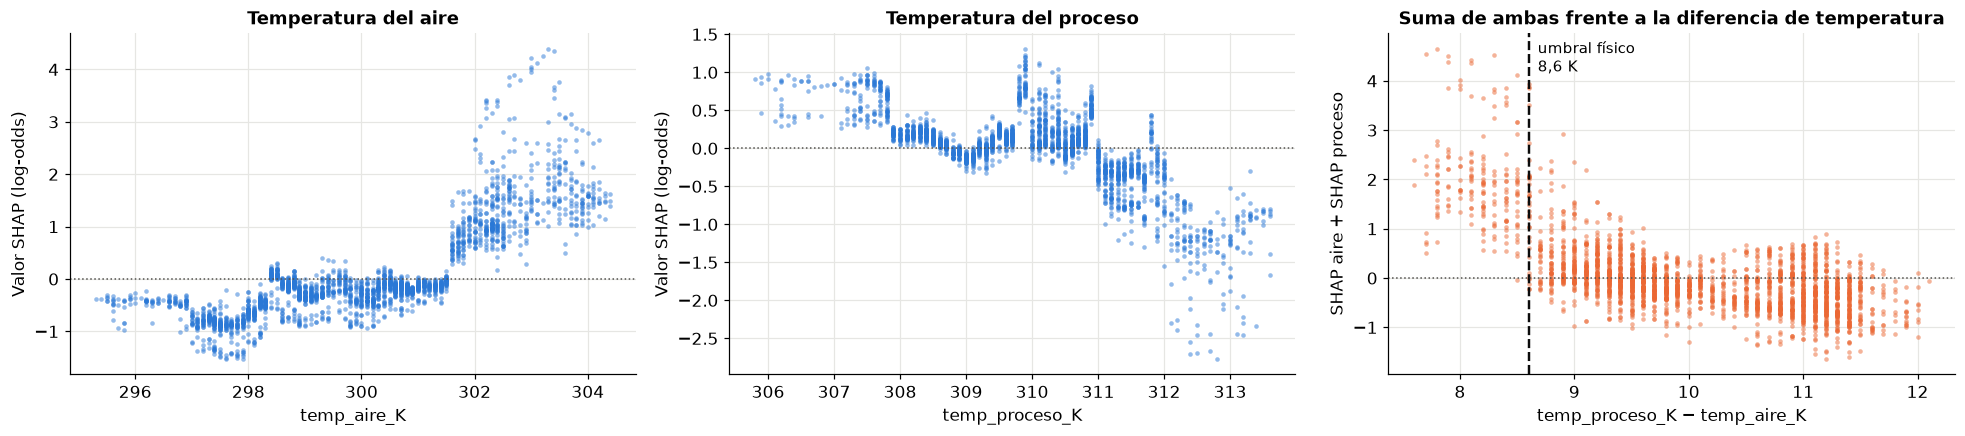

In [27]:
fig, ejes = plt.subplots(1, 3, figsize=(18, 4.1))

for eje, variable, titulo in [(ejes[0], "temp_aire_K", "Temperatura del aire"), (ejes[1], "temp_proceso_K", "Temperatura del proceso")]:
    eje.scatter(X_prueba[variable], shap_df[variable], s=9, color=AZUL, alpha=0.5, linewidths=0)
    eje.axhline(0, color=GRIS, lw=1, ls=":")
    eje.set(title=titulo, xlabel=variable, ylabel="Valor SHAP (log-odds)")

# Tercer panel: la magnitud que de verdad importa es la DIFERENCIA.
delta_prueba = X_prueba["temp_proceso_K"] - X_prueba["temp_aire_K"]
ejes[2].scatter(delta_prueba, shap_df["temp_aire_K"] + shap_df["temp_proceso_K"], s=9, color=NARANJA, alpha=0.5, linewidths=0)
ejes[2].axvline(8.6, color="#0b0b0b", ls="--", lw=1.6); ejes[2].axhline(0, color=GRIS, lw=1, ls=":")
ejes[2].annotate("umbral físico\n8,6 K", (8.6, ejes[2].get_ylim()[1]), xytext=(6, -4), textcoords="offset points", va="top", fontsize=10)
ejes[2].set(title="Suma de ambas frente a la diferencia de temperatura",
            xlabel="temp_proceso_K − temp_aire_K", ylabel="SHAP aire + SHAP proceso")
plt.tight_layout(); guardar("14_riesgo_correlacion"); plt.show()

> **Cómo leer esto.**
> - **Izquierda y centro:** vistas por separado, las dos temperaturas cuentan historias opuestas, y ninguna es clara. Alguien podría concluir «hay que enfriar el aire del taller», lo cual es una lectura equivocada.
> - **Derecha:** cuando sumamos los dos aportes y los graficamos contra la **diferencia** de temperaturas, aparece un patrón limpio con un salto justo en el umbral físico de 8,6 K.
>
> El modelo necesitaba la diferencia y solo tenía las dos temperaturas, así que la «construyó» usando una con signo positivo y la otra con signo negativo. SHAP describe con fidelidad lo que hace el modelo, pero reparte **un solo fenómeno físico entre dos variables**. Quien lea las barras sin conocer el proceso puede sacar una conclusión errónea.

El problema también afecta a la importancia por permutación. Al barajar la temperatura del aire sin tocar la del proceso, se le pide al modelo que opine sobre máquinas que **no pueden existir**:

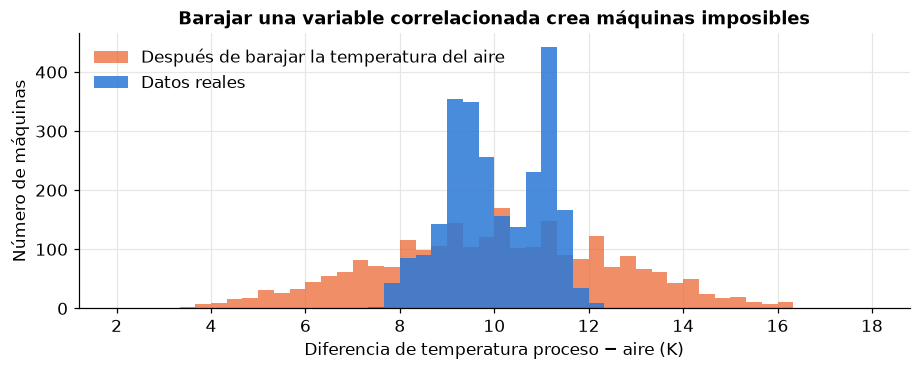

Rango real de la diferencia en todo el dataset: 7.6 a 12.1 K
Rango después de barajar:                       2.9 a 17.1 K
Máquinas barajadas fuera del rango real:         38%


In [28]:
generador = np.random.default_rng(SEMILLA)
aire_barajado = generador.permutation(X_prueba["temp_aire_K"].values)
delta_barajado = X_prueba["temp_proceso_K"].values - aire_barajado

delta_real_todos = datos["temp_proceso_K"] - datos["temp_aire_K"]
fuera_de_rango = ((delta_barajado < delta_real_todos.min()) | (delta_barajado > delta_real_todos.max())).mean()

fig, eje = plt.subplots(figsize=(8.5, 3.5))
intervalos = np.linspace(2, 18, 49)
eje.hist(delta_barajado, bins=intervalos, color=NARANJA, alpha=0.75, label="Después de barajar la temperatura del aire")
eje.hist(delta_prueba, bins=intervalos, color=AZUL, alpha=0.85, label="Datos reales")
eje.set(title="Barajar una variable correlacionada crea máquinas imposibles",
        xlabel="Diferencia de temperatura proceso − aire (K)", ylabel="Número de máquinas")
eje.legend(frameon=False)
plt.tight_layout(); guardar("15_riesgo_permutacion"); plt.show()

print(f"Rango real de la diferencia en todo el dataset: {delta_real_todos.min():.1f} a {delta_real_todos.max():.1f} K")
print(f"Rango después de barajar:                       {delta_barajado.min():.1f} a {delta_barajado.max():.1f} K")
print(f"Máquinas barajadas fuera del rango real:         {fuera_de_rango:.0%}")

> **Cómo leer esto.** En los datos reales la diferencia de temperatura siempre está en un rango estrecho (azul). Al barajar (naranja), una parte considerable de las máquinas queda con diferencias que nunca se observaron. El modelo **extrapola** sobre ellas, y la «importancia» resultante mezcla el efecto real de la variable con el comportamiento del modelo en una zona donde nunca fue entrenado. Lo mismo le ocurre al PDP.
>
> **Cómo mitigarlo:** agrupar las variables correlacionadas y analizarlas juntas, o reemplazarlas por una variable con sentido físico (lo hacemos en la sección 9).

### 8.2 Riesgo 2 — LIME puede ser inestable y poco fiel

LIME genera máquinas ficticias **al azar**. Entonces, ¿cambia la explicación si cambiamos la semilla? Explicamos la **misma máquina A** 20 veces, con 500 y con 5.000 máquinas ficticias.

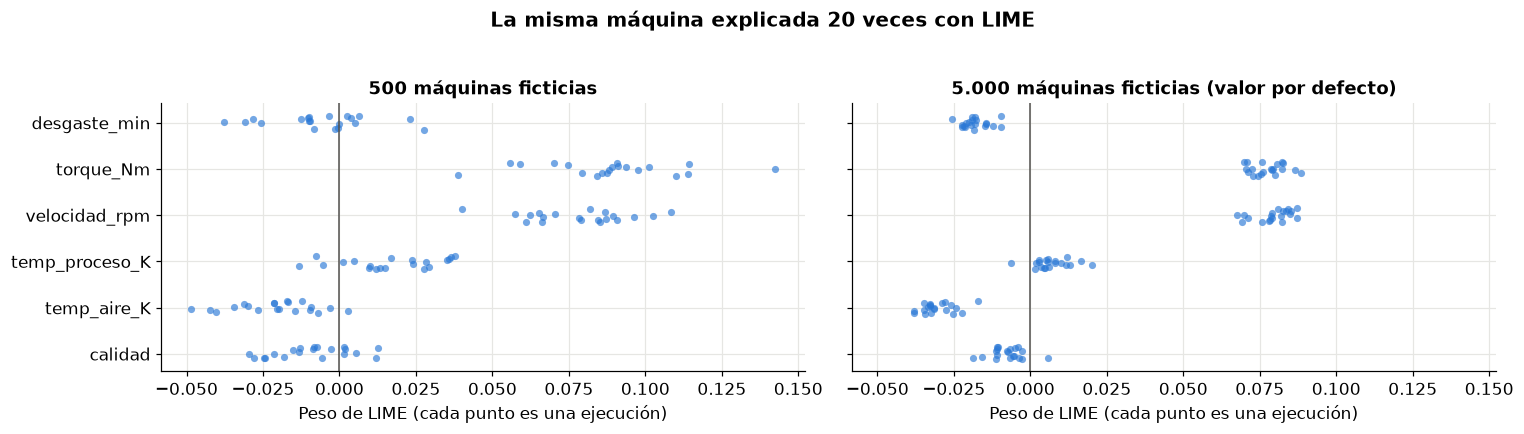

,Peso del torque: mínimo,Peso del torque: máximo,Tercera variable más importante (veces),R² del modelo local (promedio),Probabilidad según el modelo local,Probabilidad según XGBoost
500 muestras,0.039,0.143,"{'temp_aire_K': 8, 'temp_proceso_K': 7, 'calidad': 3, 'desgaste_min': 2}",0.116,0.156,0.96
5.000 muestras,0.070,0.088,"{'temp_aire_K': 18, 'desgaste_min': 2}",0.101,0.127,0.96


In [29]:
def repetir_lime(num_muestras, repeticiones=20):
    # Explica la máquina A varias veces cambiando solo la semilla; devuelve pesos, R² y predicción local.
    pesos, r2, pred_local = [], [], []
    for semilla in range(repeticiones):
        e = explicador_lime(semilla).explain_instance(
            X_prueba.values[pos_A], probabilidades, num_features=6, num_samples=num_muestras)
        pesos.append(dict(e.as_map()[1])); r2.append(e.score); pred_local.append(float(e.local_pred[0]))
    tabla_pesos = pd.DataFrame(pesos).rename(columns=dict(enumerate(VARIABLES)))[VARIABLES]
    return tabla_pesos, np.array(r2), np.array(pred_local)

lime_500, r2_500, local_500 = repetir_lime(500)
lime_5000, r2_5000, local_5000 = repetir_lime(5000)

fig, ejes = plt.subplots(1, 2, figsize=(14, 3.8), sharex=True, sharey=True)
for eje, tabla_pesos, titulo in [(ejes[0], lime_500, "500 máquinas ficticias"), (ejes[1], lime_5000, "5.000 máquinas ficticias (valor por defecto)")]:
    for i, variable in enumerate(VARIABLES):
        eje.scatter(tabla_pesos[variable], np.full(len(tabla_pesos), i) + generador.uniform(-0.16, 0.16, len(tabla_pesos)),
                    s=22, color=AZUL, alpha=0.65, linewidths=0)
    eje.axvline(0, color=GRIS, lw=1)
    eje.set_yticks(range(len(VARIABLES)), VARIABLES)
    eje.set(title=titulo, xlabel="Peso de LIME (cada punto es una ejecución)")
fig.suptitle("La misma máquina explicada 20 veces con LIME", fontweight="bold", y=1.03)
plt.tight_layout(); guardar("16_riesgo_lime_inestable"); plt.show()

def tercera_variable(tabla_pesos):
    # ¿Cuál queda en tercer lugar de importancia en cada ejecución?
    return tabla_pesos.abs().apply(lambda fila: fila.sort_values(ascending=False).index[2], axis=1).value_counts().to_dict()

estabilidad = pd.DataFrame({
    "Peso del torque: mínimo": [lime_500["torque_Nm"].min(), lime_5000["torque_Nm"].min()],
    "Peso del torque: máximo": [lime_500["torque_Nm"].max(), lime_5000["torque_Nm"].max()],
    "Tercera variable más importante (veces)": [tercera_variable(lime_500), tercera_variable(lime_5000)],
    "R² del modelo local (promedio)": [r2_500.mean(), r2_5000.mean()],
    "Probabilidad según el modelo local": [local_500.mean(), local_5000.mean()],
    "Probabilidad según XGBoost": [probabilidad_prueba[pos_A]] * 2,
}, index=["500 muestras", "5.000 muestras"])
pd.set_option("display.max_colwidth", None)
estabilidad.round(3)

> **Cómo leer esto.** Hay dos problemas distintos:
>
> 1. **Inestabilidad.** Con 500 muestras, el peso del torque cambia varias veces de tamaño de una ejecución a otra y la tercera variable más importante depende de la semilla. Con 5.000 muestras la explicación se estabiliza. Dos analistas podrían entregar explicaciones distintas de la misma alerta sin que ninguno haya cometido un error.
> 2. **Baja fidelidad.** Mira las tres últimas columnas. El modelo lineal local tiene un **R² muy bajo** y, para esta máquina, predice una probabilidad de falla muy inferior a la que da XGBoost. Es decir: la explicación describe un modelo sencillo que **no se parece** a la caja negra en ese punto. La región de falla es pequeña y de bordes curvos, y una recta no la puede seguir.
>
> LIME acertó en las dos variables principales, pero su gráfico de barras no avisa de ninguno de estos dos problemas.
>
> **Cómo mitigarlo:** repetir la explicación con varias semillas, usar suficientes muestras, revisar siempre el R² del modelo local y contrastar con otro método.

### 8.3 Riesgo 3 — Una explicación convincente no es una predicción correcta

SHAP explica **lo que hizo el modelo**, acierte o no. Miremos una falla que el modelo **no detectó**.

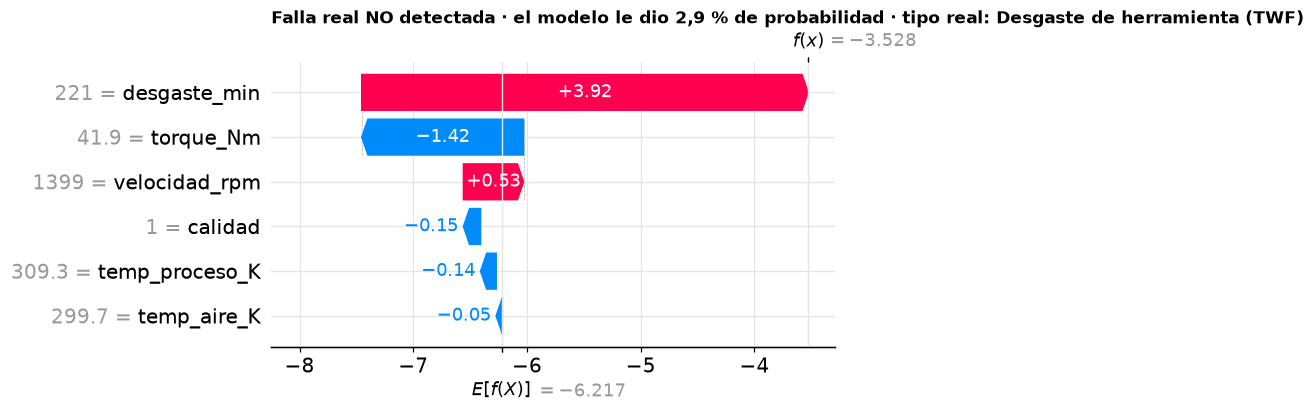

,Fallas en la prueba,Detectadas,No detectadas
Tipo de falla,,,
Desgaste de herramienta (TWF),13,1,12
Disipación de calor (HDF),36,25,11
Potencia (PWF),17,14,3
Sobrecarga (OSF),20,18,2


In [30]:
# Primera falla por desgaste de herramienta (TWF) de la prueba que el modelo dejó pasar.
no_detectada = (prediccion_prueba == 0) & (y_prueba.values == 1)
pos_twf = int(np.where((prueba_original["TWF"].values == 1) & un_solo_modo & no_detectada)[0][0])

cascada(pos_twf, f"Falla real NO detectada · el modelo le dio {porcentaje(probabilidad_prueba[pos_twf], 1)} de probabilidad · "
                 f"tipo real: {NOMBRE_MODO['TWF']} (TWF)", "17_riesgo_falla_no_detectada")

# ¿Cómo le fue al modelo con cada tipo de falla?
fallas_prueba = prueba_original[y_prueba.values == 1]
detectada = pd.Series(prediccion_prueba[y_prueba.values == 1] == 1, index=fallas_prueba.index)
pd.DataFrame([{
    "Tipo de falla": f"{NOMBRE_MODO[m]} ({m})",
    "Fallas en la prueba": int(fallas_prueba[m].sum()),
    "Detectadas": int(detectada[fallas_prueba[m] == 1].sum()),
    "No detectadas": int((~detectada[fallas_prueba[m] == 1]).sum()),
} for m in ["TWF", "HDF", "PWF", "OSF"]]).set_index("Tipo de falla")

> **Cómo leer esto.** El gráfico tiene exactamente el mismo aspecto ordenado que los de la sección 6: el desgaste alto empuja hacia falla y las demás variables lo compensan. Parece una explicación razonable, y sin embargo corresponde a una **predicción equivocada**: la máquina falló.
>
> ¿Por qué el modelo casi nunca detecta este tipo? Porque es aleatorio por diseño: la herramienta falla en algún momento entre 200 y 240 minutos, y con las variables disponibles no se puede saber cuándo. El modelo hace lo correcto al dar una probabilidad baja; simplemente no hay información para más.
>
> **Tres lecciones:**
> - Una explicación con buen aspecto **no valida** la predicción. Siempre hay que mirar las métricas junto con las explicaciones.
> - SHAP explica **el modelo, no el mundo**. Si el modelo está mal, la explicación describe fielmente un error.
> - **Explicar no es establecer causalidad.** Que el desgaste tenga un valor SHAP alto significa que el modelo lo usa, no que intervenir sobre él vaya a cambiar el resultado. Para afirmar causalidad hacen falta experimentos o métodos de inferencia causal.

### 8.4 Resumen de riesgos

| Riesgo | Qué observamos en este ejemplo | Cómo reducirlo |
|---|---|---|
| Variables correlacionadas | Dos temperaturas con efectos opuestos que en realidad son un solo fenómeno; máquinas imposibles al barajar | Agrupar variables, usar variables con sentido físico |
| Inestabilidad | LIME cambia con la semilla cuando hay pocas muestras | Repetir, aumentar muestras, reportar la variabilidad |
| Baja fidelidad local | El modelo lineal de LIME no reproduce la predicción de XGBoost | Revisar el R² local; contrastar con SHAP |
| Falsa confianza | Una explicación ordenada de una predicción equivocada | Evaluar siempre el modelo además de explicarlo |
| Confundir con causalidad | «El modelo usa X» no es «X causa la falla» | Conocimiento del proceso, experimentos |

<a id="s9"></a>
## 9. Cerrar el ciclo: de explicar la caja negra a no necesitarla

Las explicaciones nos dejaron tres pistas, y el conocimiento del proceso permite convertirlas en magnitudes físicas:

| Lo que mostraron las explicaciones | Dónde | Cómo lo lee un ingeniero mecánico | Variable física |
|---|---|---|---|
| Velocidad y torque interactúan; el torque es peligroso en los dos extremos | 5.4.3, 5.4.4, 7.3 | Potencia mecánica | $P = \tau \cdot \omega$, con $\omega = \text{rpm}\cdot 2\pi/60$ |
| Torque y desgaste interactúan | 5.4.4, 7.3 | Carga acumulada sobre la herramienta | $\text{desgaste} \cdot \tau$ |
| Las dos temperaturas actúan como una resta | 5.4.4, 8.1 | Capacidad de disipar calor | $\Delta T = T_{proceso} - T_{aire}$ |

Hay una postura muy conocida en XAI (Rudin, 2019): en decisiones de alto impacto, antes de *explicar* una caja negra conviene intentar construir un modelo **interpretable por diseño**. Probemos: creamos esas tres variables y entrenamos de nuevo un **árbol de decisión pequeño**, el mismo tipo de modelo que fracasó en la sección 3.

In [31]:
def variables_fisicas(tabla):
    # Añade las tres magnitudes físicas y devuelve el conjunto de variables para el árbol.
    t = tabla.copy()
    t["delta_T_K"] = t["temp_proceso_K"] - t["temp_aire_K"]
    t["potencia_W"] = t["torque_Nm"] * t["velocidad_rpm"] * 2 * np.pi / 60
    t["sobrecarga_minNm"] = t["desgaste_min"] * t["torque_Nm"]
    return t[["calidad", "delta_T_K", "velocidad_rpm", "potencia_W", "sobrecarga_minNm", "desgaste_min"]]

F_entrena, F_prueba = variables_fisicas(X_entrena), variables_fisicas(X_prueba)
VARIABLES_FISICAS = list(F_entrena.columns)

# Elegimos la profundidad con validación cruzada usando SOLO el entrenamiento (la prueba no se toca).
validacion_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
busqueda = GridSearchCV(DecisionTreeClassifier(random_state=SEMILLA), {"max_depth": [2, 3, 4, 5, 6]},
                        scoring="f1", cv=validacion_cruzada)
busqueda.fit(F_entrena, y_entrena)

display(pd.DataFrame({"Profundidad": busqueda.cv_results_["param_max_depth"],
                      "F1 promedio en validación cruzada": busqueda.cv_results_["mean_test_score"].round(3)}).set_index("Profundidad").T)

arbol_fisico = busqueda.best_estimator_
print(f"Profundidad elegida: {arbol_fisico.get_depth()}  |  Reglas finales (hojas): {arbol_fisico.get_n_leaves()}")
evaluar("Árbol con variables físicas", arbol_fisico, F_prueba, interpretable=True)

Profundidad,2,3,4,5,6
F1 promedio en validación cruzada,0.603,0.711,0.711,0.891,0.878


Profundidad elegida: 5  |  Reglas finales (hojas): 10


,¿Se lee directamente?,Precisión,Sensibilidad,F1,PR-AUC,Fallas detectadas,Falsas alarmas
Modelo,,,,,,,
Árbol con variables físicas,Sí,0.946,0.824,0.881,0.846,70 de 85,4


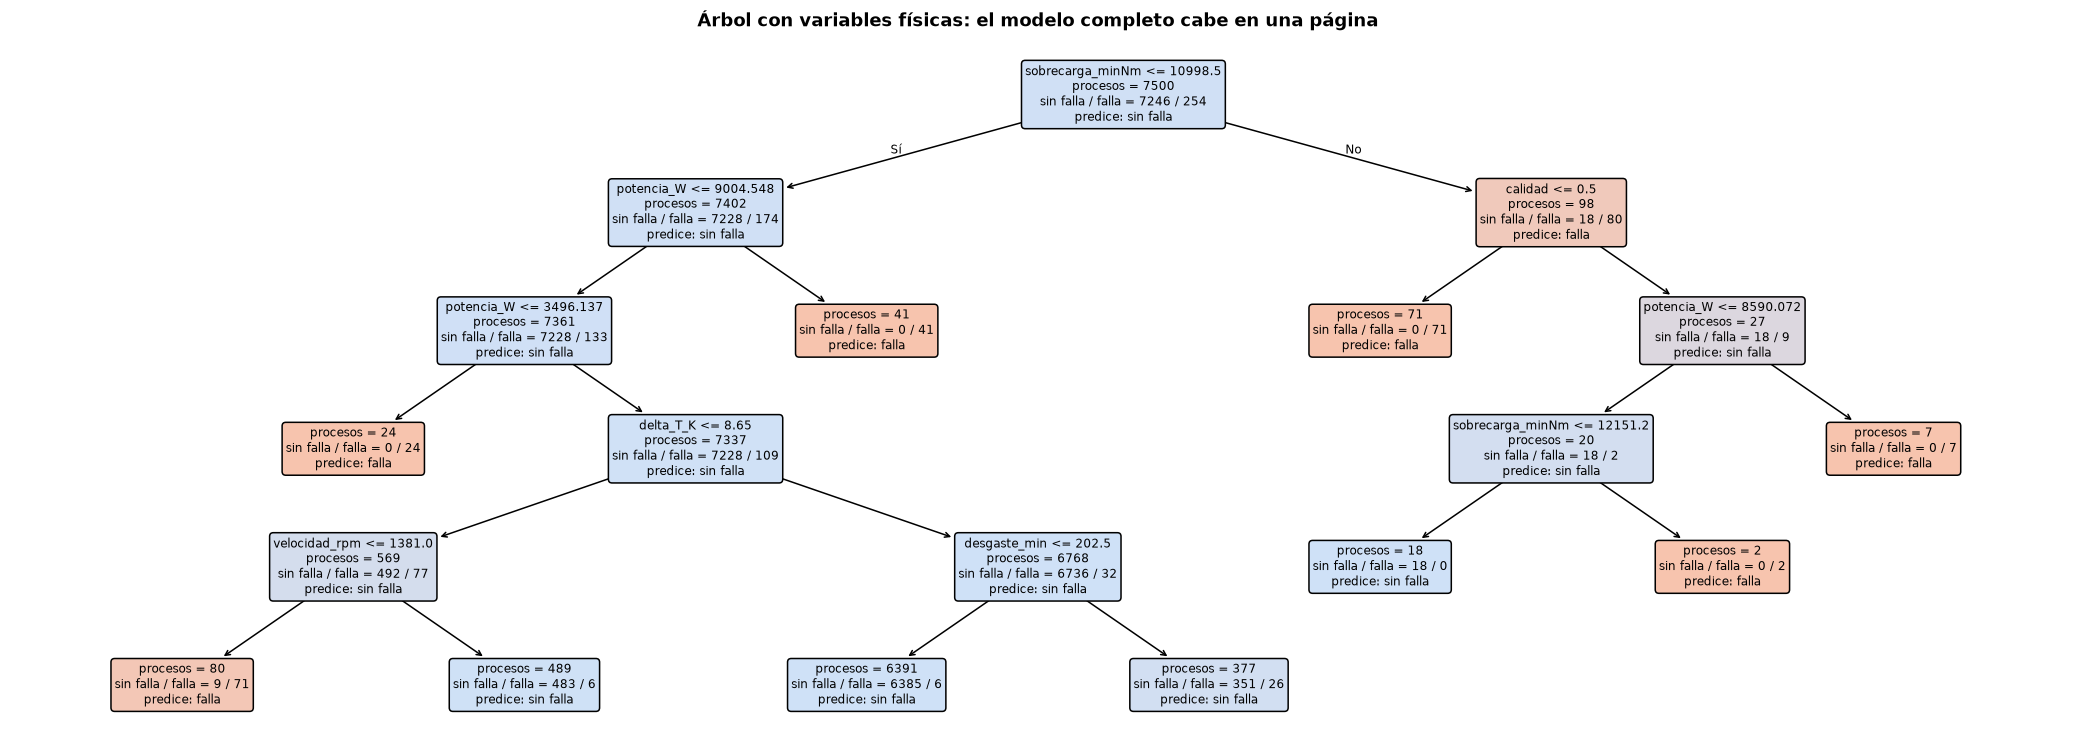

In [32]:
fig, eje = plt.subplots(figsize=(19, 7))
dibujar_arbol(arbol_fisico, VARIABLES_FISICAS, eje, tamano_letra=8)
eje.set_title("Árbol con variables físicas: el modelo completo cabe en una página")
plt.tight_layout(); guardar("18_arbol_fisico"); plt.show()

El árbol completo se puede leer. Comparemos los umbrales que **aprendió de los datos** con los que están en la documentación del dataset:

In [33]:
# Extraemos del árbol los cortes más cercanos a cada umbral documentado.
arbol_interno = arbol_fisico.tree_
cortes = pd.DataFrame({"variable": [VARIABLES_FISICAS[i] for i in arbol_interno.feature[arbol_interno.feature >= 0]],
                       "umbral": arbol_interno.threshold[arbol_interno.feature >= 0]})

UMBRALES_REALES = [("Sobrecarga, calidad L", "sobrecarga_minNm", 11000),
                   ("Sobrecarga, calidad M", "sobrecarga_minNm", 12000),
                   ("Potencia máxima", "potencia_W", 9000),
                   ("Potencia mínima", "potencia_W", 3500),
                   ("Diferencia de temperatura", "delta_T_K", 8.6),
                   ("Velocidad (disipación de calor)", "velocidad_rpm", 1380)]
filas = []
for descripcion, variable, real in UMBRALES_REALES:
    candidatos = cortes.loc[cortes["variable"] == variable, "umbral"]
    if len(candidatos):
        aprendido = candidatos.iloc[(candidatos - real).abs().argmin()]
        filas.append({"Regla": descripcion, "Variable": variable, "Umbral real (documentación)": real,
                      "Umbral aprendido por el árbol": round(float(aprendido), 2),
                      "Diferencia": f"{abs(aprendido - real) / real:.2%}"})
pd.DataFrame(filas).set_index("Regla")

,Variable,Umbral real (documentación),Umbral aprendido por el árbol,Diferencia
Regla,,,,
"Sobrecarga, calidad L",sobrecarga_minNm,11000.0,10998.50,0.01%
"Sobrecarga, calidad M",sobrecarga_minNm,12000.0,12151.20,1.26%
Potencia máxima,potencia_W,9000.0,9004.55,0.05%
Potencia mínima,potencia_W,3500.0,3496.14,0.11%
Diferencia de temperatura,delta_T_K,8.6,8.65,0.58%
Velocidad (disipación de calor),velocidad_rpm,1380.0,1381.00,0.07%


> **Cómo leer esto.** El árbol **redescubrió las reglas físicas** casi con los mismos números de la documentación, a partir de los datos y sin que nadie se las dijera. Y cada alerta se explica sola: basta con seguir el camino por el árbol.

### 9.1 Comparación final

,¿Se lee directamente?,Precisión,Sensibilidad,F1,PR-AUC,Fallas detectadas,Falsas alarmas
Modelo,,,,,,,
Regresión logística,Sí,0.600,0.141,0.229,0.408,12 de 85,8
Árbol de decisión (profundidad 3),Sí,0.800,0.188,0.305,0.273,16 de 85,4
XGBoost (caja negra),No,0.859,0.647,0.738,0.797,55 de 85,9
Árbol con variables físicas,Sí,0.946,0.824,0.881,0.846,70 de 85,4


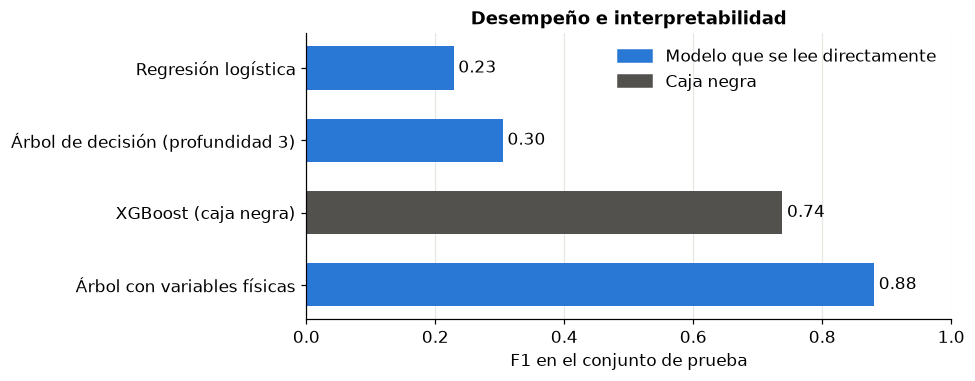

In [34]:
tabla_final = pd.DataFrame(resultados).set_index("Modelo")
display(tabla_final.round(3))

fig, eje = plt.subplots(figsize=(9, 3.6))
colores = [AZUL if s == "Sí" else GRIS for s in tabla_final["¿Se lee directamente?"]]
barras = eje.barh(tabla_final.index[::-1], tabla_final["F1"][::-1], color=colores[::-1], height=0.6)
eje.bar_label(barras, fmt="%.2f", padding=3)
eje.set(xlim=(0, 1), xlabel="F1 en el conjunto de prueba", title="Desempeño e interpretabilidad")
eje.grid(axis="y", visible=False)
eje.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=AZUL), plt.Rectangle((0, 0), 1, 1, color=GRIS)],
           labels=["Modelo que se lee directamente", "Caja negra"], frameon=False, loc="upper right")
plt.tight_layout(); guardar("19_comparacion_final"); plt.show()

Una sola división de prueba puede favorecer a un modelo por azar. Repetimos la comparación con **validación cruzada de 5 particiones** sobre todo el dataset:

In [35]:
def xgboost_nuevo():
    return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                         eval_metric="logloss", enable_categorical=False, n_jobs=2, random_state=SEMILLA)

candidatos = {
    "Regresión logística": (make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), X),
    "Árbol de decisión (profundidad 3)": (DecisionTreeClassifier(max_depth=3, random_state=SEMILLA), X),
    "XGBoost (caja negra)": (xgboost_nuevo(), X),
    "XGBoost con variables físicas": (xgboost_nuevo(), variables_fisicas(X)),
    "Árbol con variables físicas": (DecisionTreeClassifier(max_depth=arbol_fisico.get_depth(), random_state=SEMILLA), variables_fisicas(X)),
}
filas = []
for nombre, (estimador, matriz) in candidatos.items():
    cv = cross_validate(estimador, matriz, y, cv=validacion_cruzada, scoring=["precision", "recall", "f1", "average_precision"])
    filas.append({"Modelo": nombre,
                  "Precisión": cv["test_precision"].mean(), "Sensibilidad": cv["test_recall"].mean(),
                  "F1 (promedio)": cv["test_f1"].mean(), "F1 (desv. estándar)": cv["test_f1"].std(),
                  "PR-AUC": cv["test_average_precision"].mean()})
tabla_cv = pd.DataFrame(filas).set_index("Modelo")
tabla_cv.round(3)

,Precisión,Sensibilidad,F1 (promedio),F1 (desv. estándar),PR-AUC
Modelo,,,,,
Regresión logística,0.734,0.183,0.289,0.061,0.463
Árbol de decisión (profundidad 3),0.845,0.206,0.331,0.016,0.291
XGBoost (caja negra),0.875,0.611,0.715,0.069,0.798
XGBoost con variables físicas,0.916,0.782,0.843,0.008,0.885
Árbol con variables físicas,0.976,0.823,0.893,0.012,0.861


> **Cómo leer esto.** El resultado se mantiene con validación cruzada: el árbol pequeño con variables físicas supera a la caja negra original tanto en F1 como en PR-AUC, y además se lee completo. Darle las mismas variables físicas a XGBoost también lo mejora mucho (y le da el PR-AUC más alto de la tabla), lo que confirma que la ganancia viene del **conocimiento del proceso** y no del tipo de modelo.
>
> **Tres matices para no exagerar la conclusión:**
> - Este dataset es **sintético** y sus fallas siguen reglas nítidas. En datos reales las fronteras son difusas, hay ruido de sensores y las reglas no se conocen de antemano; ahí una caja negra puede conservar ventaja.
> - Conocíamos la física del proceso. XAI nos dio las pistas, pero convertirlas en variables requirió **conocimiento del dominio**.
> - Ningún modelo puede anticipar las fallas aleatorias. Hay un techo de desempeño que no depende del algoritmo.
>
> La lección general sí se sostiene: **XAI no es solo para justificar un modelo; sirve para aprender del modelo y construir uno mejor.**

<a id="s10"></a>
## 10. Conclusiones

1. **Predecir no basta.** Un modelo que avisa de una falla sin decir por qué no se puede convertir en una acción de mantenimiento.
2. **Hay una tensión real entre desempeño e interpretabilidad.** Con las variables originales, los modelos transparentes detectaron muy pocas fallas y XGBoost muchas más.
3. **Cada método responde una pregunta distinta.** Permutación dice *cuánto* importa una variable; PDP/ICE dice *cómo* cambia la predicción; SHAP reparte cada predicción con garantías teóricas; LIME aproxima localmente con un modelo sencillo.
4. **Las explicaciones se pueden y se deben validar.** Aquí las contrastamos con reglas físicas conocidas, y SHAP señaló las causas correctas en la gran mayoría de los casos.
5. **XAI tiene riesgos propios:** variables correlacionadas, inestabilidad, baja fidelidad y explicaciones convincentes de predicciones erróneas. Una explicación describe al modelo, no a la realidad, y no demuestra causalidad.
6. **El mejor resultado vino de combinar XAI con conocimiento de ingeniería:** las explicaciones sugirieron tres variables físicas, y con ellas un árbol legible de 10 reglas superó a la caja negra original.

## Referencias

- Matzka, S. (2020). *Explainable Artificial Intelligence for Predictive Maintenance Applications*. Third International Conference on Artificial Intelligence for Industries (AI4I). Dataset: UCI Machine Learning Repository, DOI 10.24432/C5HS5C.
- Lundberg, S. M. y Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS.
- Lundberg, S. M. et al. (2020). *From local explanations to global understanding with explainable AI for trees*. Nature Machine Intelligence.
- Ribeiro, M. T., Singh, S. y Guestrin, C. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier*. KDD.
- Friedman, J. H. (2001). *Greedy Function Approximation: A Gradient Boosting Machine*. Annals of Statistics. (Dependencia parcial)
- Goldstein, A. et al. (2015). *Peeking Inside the Black Box: Visualizing Statistical Learning with Plots of Individual Conditional Expectation*. Journal of Computational and Graphical Statistics.
- Breiman, L. (2001). *Random Forests*. Machine Learning. (Importancia por permutación)
- Hooker, G., Mentch, L. y Zhou, S. (2021). *Unrestricted permutation forces extrapolation: variable importance requires at least one more model, or there is no free variable importance*. Statistics and Computing.
- Alvarez-Melis, D. y Jaakkola, T. (2018). *On the Robustness of Interpretability Methods*. ICML Workshop on Human Interpretability in Machine Learning.
- Rudin, C. (2019). *Stop explaining black box machine learning models for high stakes decisions and use interpretable models instead*. Nature Machine Intelligence.
- Molnar, C. *Interpretable Machine Learning: A Guide for Making Black Box Models Explainable*. Libro abierto: https://christophm.github.io/interpretable-ml-book/